In [1]:

# URBANFLOW AI ETA V2 SETUP


from google.colab import drive
drive.mount('/content/drive')

import os
import gc
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

PROJECT_DIR = (
    "/content/drive/MyDrive/"
    "UrbanFlow_Datathon_2026"
)

DATA_DIR = os.path.join(
    PROJECT_DIR,
    "data"
)

ETA_DIR = os.path.join(
    PROJECT_DIR,
    "duration_model_v3"
)

FOLD_DIR = os.path.join(
    ETA_DIR,
    "rolling_folds"
)

MODEL_DIR = os.path.join(
    ETA_DIR,
    "models"
)

RESULT_DIR = os.path.join(
    ETA_DIR,
    "results"
)

for folder in [
    ETA_DIR,
    FOLD_DIR,
    MODEL_DIR,
    RESULT_DIR
]:
    os.makedirs(folder, exist_ok=True)


CLEAN_PATH = os.path.join(
    DATA_DIR,
    "trips_clean.parquet"
)

assert os.path.exists(CLEAN_PATH), (
    f"Clean dataset not found:\n{CLEAN_PATH}"
)

print("Project ready.")
print("Clean data:", CLEAN_PATH)
print("ETA folder :", ETA_DIR)

Mounted at /content/drive
Project ready.
Clean data: /content/drive/MyDrive/UrbanFlow_Datathon_2026/data/trips_clean.parquet
ETA folder : /content/drive/MyDrive/UrbanFlow_Datathon_2026/duration_model_v3


In [2]:

# CLEAN DATASET METADATA

pf = pq.ParquetFile(CLEAN_PATH)

print("=" * 65)
print("CLEAN MASTER DATASET")
print("=" * 65)

print(f"Rows       : {pf.metadata.num_rows:,}")
print(f"Columns    : {pf.metadata.num_columns}")
print(f"Row groups : {pf.num_row_groups}")
print(
    f"Size       : "
    f"{os.path.getsize(CLEAN_PATH)/(1024**3):.2f} GB"
)

print("\nColumns:")

for i, name in enumerate(
    pf.schema_arrow.names,
    start=1
):
    print(i, name)

CLEAN MASTER DATASET
Rows       : 44,286,676
Columns    : 22
Row groups : 523
Size       : 1.14 GB

Columns:
1 provider_code
2 pickup_timestamp
3 dropoff_timestamp
4 rider_count
5 distance_miles
6 rate_class_id
7 offline_record_flag
8 origin_loc_id
9 dest_loc_id
10 fare_settlement_method
11 base_fare
12 surcharge_misc
13 transit_tax
14 driver_tip_payment
15 toll_total
16 service_improvement_fee
17 charge_total
18 zone_congestion_fee
19 Airport_fee
20 congestion_relief_fee
21 trip_duration_minutes
22 speed_mph


In [3]:
#  MONTHLY COVERAGE

monthly_info = {}

overall_min = None
overall_max = None

for rg in range(pf.num_row_groups):

    temp = (
        pf.read_row_group(
            rg,
            columns=["pickup_timestamp"]
        )
        .to_pandas()
    )

    ts = pd.to_datetime(
        temp["pickup_timestamp"]
    )

    rg_min = ts.min()
    rg_max = ts.max()

    if overall_min is None or rg_min < overall_min:
        overall_min = rg_min

    if overall_max is None or rg_max > overall_max:
        overall_max = rg_max

    month_series = ts.dt.to_period("M")

    for month in month_series.unique():

        mask = month_series == month

        m_min = ts[mask].min()
        m_max = ts[mask].max()
        count = int(mask.sum())

        if month not in monthly_info:

            monthly_info[month] = {
                "Trips": count,
                "First_Timestamp": m_min,
                "Last_Timestamp": m_max
            }

        else:

            monthly_info[month]["Trips"] += count

            monthly_info[month]["First_Timestamp"] = min(
                monthly_info[month]["First_Timestamp"],
                m_min
            )

            monthly_info[month]["Last_Timestamp"] = max(
                monthly_info[month]["Last_Timestamp"],
                m_max
            )

    del temp
    gc.collect()

    if (rg + 1) % 50 == 0:
        print(
            f"Processed {rg+1}/{pf.num_row_groups}"
        )


month_df = (
    pd.DataFrame
    .from_dict(
        monthly_info,
        orient="index"
    )
    .reset_index()
    .rename(columns={"index": "Month"})
    .sort_values("Month")
    .reset_index(drop=True)
)

month_df["Percentage"] = (
    month_df["Trips"]
    / month_df["Trips"].sum()
    * 100
)

print("\nDATA COVERAGE")
print("=" * 65)

print("First timestamp:", overall_min)
print("Last timestamp :", overall_max)
print("Months found   :", len(month_df))
print("Total trips    :", f"{month_df['Trips'].sum():,}")

display(
    month_df.style.format({
        "Trips": "{:,}",
        "Percentage": "{:.2f}%"
    })
)

Processed 50/523
Processed 100/523
Processed 150/523
Processed 200/523
Processed 250/523
Processed 300/523
Processed 350/523
Processed 400/523
Processed 450/523
Processed 500/523

DATA COVERAGE
First timestamp: 2025-04-01 00:00:00
Last timestamp : 2026-03-31 23:59:59
Months found   : 12
Total trips    : 44,286,676


,Month,Trips,First_Timestamp,Last_Timestamp,Percentage
0,2025-04,"3,672,531",2025-04-01 00:00:00,2025-04-30 23:59:59,8.29%
1,2025-05,"4,093,408",2025-05-01 00:00:00,2025-05-31 23:59:58,9.24%
2,2025-06,"3,870,028",2025-06-01 00:00:00,2025-06-30 23:59:59,8.74%
3,2025-07,"3,495,214",2025-07-01 00:00:00,2025-07-31 23:59:59,7.89%
4,2025-08,"3,181,272",2025-08-01 00:00:01,2025-08-31 23:59:59,7.18%
5,2025-09,"3,838,913",2025-09-01 00:00:00,2025-09-30 23:59:59,8.67%
6,2025-10,"3,944,775",2025-10-01 00:00:00,2025-10-31 23:59:59,8.91%
7,2025-11,"3,644,999",2025-11-01 00:00:00,2025-11-30 23:59:59,8.23%
8,2025-12,"4,051,172",2025-12-01 00:00:00,2025-12-31 23:59:57,9.15%
9,2026-01,"3,518,171",2026-01-01 00:00:00,2026-01-31 23:59:59,7.94%


In [4]:
#  IDENTIFY COMPLETE MONTHS


import calendar

def is_complete_month(row):

    month = row["Month"]

    year = month.year
    mon = month.month

    last_day = calendar.monthrange(
        year,
        mon
    )[1]

    first_ts = row["First_Timestamp"]
    last_ts = row["Last_Timestamp"]

    first_ok = first_ts.day <= 1

    last_ok = last_ts.day >= last_day

    return first_ok and last_ok


month_df["Complete_Month"] = month_df.apply(
    is_complete_month,
    axis=1
)

display(month_df)

complete_months = (
    month_df.loc[
        month_df["Complete_Month"],
        "Month"
    ]
    .tolist()
)

print("\nComplete months:")

for m in complete_months:
    print(m)

print(
    "\nNumber of complete months:",
    len(complete_months)
)

,Month,Trips,First_Timestamp,Last_Timestamp,Percentage,Complete_Month
0,2025-04,3672531,2025-04-01 00:00:00,2025-04-30 23:59:59,8.292632,True
1,2025-05,4093408,2025-05-01 00:00:00,2025-05-31 23:59:58,9.242979,True
2,2025-06,3870028,2025-06-01 00:00:00,2025-06-30 23:59:59,8.738583,True
3,2025-07,3495214,2025-07-01 00:00:00,2025-07-31 23:59:59,7.892247,True
4,2025-08,3181272,2025-08-01 00:00:01,2025-08-31 23:59:59,7.183361,True
5,2025-09,3838913,2025-09-01 00:00:00,2025-09-30 23:59:59,8.668325,True
6,2025-10,3944775,2025-10-01 00:00:00,2025-10-31 23:59:59,8.907363,True
7,2025-11,3644999,2025-11-01 00:00:00,2025-11-30 23:59:59,8.230464,True
8,2025-12,4051172,2025-12-01 00:00:00,2025-12-31 23:59:57,9.147609,True
9,2026-01,3518171,2026-01-01 00:00:00,2026-01-31 23:59:59,7.944085,True



Complete months:
2025-04
2025-05
2025-06
2025-07
2025-08
2025-09
2025-10
2025-11
2025-12
2026-01
2026-02
2026-03

Number of complete months: 12


In [5]:
#  TEMPORAL EVALUATION DESIGN


assert len(complete_months) >= 6, (
    "Need at least 6 complete months "
    "for this rolling-origin design."
)

FINAL_TEST_MONTH = complete_months[-1]

DEVELOPMENT_MONTHS = complete_months[:-1]

print("=" * 65)
print("TEMPORAL DESIGN")
print("=" * 65)

print(
    "Final untouched test month:",
    FINAL_TEST_MONTH
)

print("\nDevelopment months:")

for m in DEVELOPMENT_MONTHS:
    print(m)

TEMPORAL DESIGN
Final untouched test month: 2026-03

Development months:
2025-04
2025-05
2025-06
2025-07
2025-08
2025-09
2025-10
2025-11
2025-12
2026-01
2026-02


In [6]:
# CELL 6 — ROLLING-ORIGIN VALIDATION FOLDS


N_VALIDATION_FOLDS = min(
    4,
    len(DEVELOPMENT_MONTHS) - 2
)

VALIDATION_MONTHS = (
    DEVELOPMENT_MONTHS[
        -N_VALIDATION_FOLDS:
    ]
)

print("Rolling validation months:")

for val_month in VALIDATION_MONTHS:

    train_months = [
        m
        for m in DEVELOPMENT_MONTHS
        if m < val_month
    ]

    print(
        f"\nValidation: {val_month}"
    )

    print(
        f"Training history: "
        f"{train_months[0]} "
        f"to {train_months[-1]}"
    )

Rolling validation months:

Validation: 2025-11
Training history: 2025-04 to 2025-10

Validation: 2025-12
Training history: 2025-04 to 2025-11

Validation: 2026-01
Training history: 2025-04 to 2025-12

Validation: 2026-02
Training history: 2025-04 to 2026-01


In [7]:
# CELL 7 — DEVELOPMENT MODE


USE_SAMPLE = True

SAMPLE_FRAC = 0.05

RANDOM_STATE = 42

SAMPLE_PATH = os.path.join(
    ETA_DIR,
    "eta_month_stratified_sample.parquet"
)

print(
    "Mode:",
    "SAMPLE" if USE_SAMPLE else "FULL"
)

print(
    "Sample fraction:",
    SAMPLE_FRAC
)

Mode: SAMPLE
Sample fraction: 0.05


In [8]:
#  CELL 8 — CREATE TEMPORAL DEVELOPMENT SAMPLE


SAFE_COLS = [
    "pickup_timestamp",
    "trip_duration_minutes",

    "provider_code",
    "rider_count",
    "rate_class_id",
    "offline_record_flag",

    "origin_loc_id",
    "dest_loc_id"
]


if USE_SAMPLE and not os.path.exists(SAMPLE_PATH):

    print(
        "Creating month-preserving "
        "development sample..."
    )

    rng = np.random.default_rng(
        RANDOM_STATE
    )

    sampled_parts = []

    for rg in range(pf.num_row_groups):

        part = (
            pf.read_row_group(
                rg,
                columns=SAFE_COLS
            )
            .to_pandas()
        )

        month = (
            part["pickup_timestamp"]
            .dt.to_period("M")
        )

        keep = np.zeros(
            len(part),
            dtype=bool
        )

        for m in month.unique():

            idx = np.where(
                month.values == m
            )[0]

            n_keep = max(
                1,
                int(
                    len(idx)
                    * SAMPLE_FRAC
                )
            )

            chosen = rng.choice(
                idx,
                size=n_keep,
                replace=False
            )

            keep[chosen] = True

        sampled_parts.append(
            part.loc[keep].copy()
        )

        del part
        gc.collect()

        if (rg + 1) % 50 == 0:

            print(
                f"Processed "
                f"{rg+1}/{pf.num_row_groups}"
            )


    dev_df = pd.concat(
        sampled_parts,
        ignore_index=True
    )

    dev_df = dev_df.sort_values(
        "pickup_timestamp"
    ).reset_index(drop=True)

    dev_df.to_parquet(
        SAMPLE_PATH,
        index=False
    )

    del sampled_parts

    gc.collect()

    print("\nSaved:")
    print(SAMPLE_PATH)

else:

    print(
        "Existing development "
        "sample found."
    )

Creating month-preserving development sample...
Processed 50/523
Processed 100/523
Processed 150/523
Processed 200/523
Processed 250/523
Processed 300/523
Processed 350/523
Processed 400/523
Processed 450/523
Processed 500/523

Saved:
/content/drive/MyDrive/UrbanFlow_Datathon_2026/duration_model_v3/eta_month_stratified_sample.parquet


In [9]:
#  CELL 9 — LOAD ETA DEVELOPMENT DATA

if USE_SAMPLE:

    df = pd.read_parquet(
        SAMPLE_PATH
    )

else:

    df = pd.read_parquet(
        CLEAN_PATH,
        columns=SAFE_COLS
    )


df = df.sort_values(
    "pickup_timestamp"
).reset_index(drop=True)

df["month_period"] = (
    df["pickup_timestamp"]
    .dt.to_period("M")
)


print("Shape:", df.shape)

print("\nDate range:")

print(
    df["pickup_timestamp"].min(),
    "→",
    df["pickup_timestamp"].max()
)

print("\nMonthly counts:")

display(
    df["month_period"]
    .value_counts()
    .sort_index()
)

Shape: (2214092, 9)

Date range:
2025-04-01 00:00:03 → 2026-03-31 23:58:55

Monthly counts:


,count
month_period,
2025-04,183606
2025-05,204654
2025-06,193480
2025-07,174741
2025-08,159045
2025-09,191924
2025-10,197218
2025-11,182230
2025-12,202535


In [10]:
#  CELL 10 — STATIC ETA FEATURES

df["pickup_hour"] = (
    df["pickup_timestamp"]
    .dt.hour
    .astype("int8")
)

df["pickup_dow"] = (
    df["pickup_timestamp"]
    .dt.dayofweek
    .astype("int8")
)

df["pickup_month"] = (
    df["pickup_timestamp"]
    .dt.month
    .astype("int8")
)

df["pickup_day"] = (
    df["pickup_timestamp"]
    .dt.day
    .astype("int8")
)

df["pickup_week"] = (
    df["pickup_timestamp"]
    .dt.isocalendar()
    .week
    .astype("int16")
)

df["is_weekend"] = (
    df["pickup_dow"]
    .isin([5, 6])
    .astype("int8")
)

df["is_rush_hour"] = (
    df["pickup_hour"]
    .isin([
        7, 8, 9,
        16, 17, 18, 19
    ])
    .astype("int8")
)

df["is_night"] = (
    df["pickup_hour"]
    .isin([
        0, 1, 2, 3, 4, 5,
        22, 23
    ])
    .astype("int8")
)

df["same_zone"] = (
    df["origin_loc_id"]
    == df["dest_loc_id"]
).astype("int8")


# Cyclical encodings

df["hour_sin"] = np.sin(
    2 * np.pi
    * df["pickup_hour"] / 24
).astype("float32")

df["hour_cos"] = np.cos(
    2 * np.pi
    * df["pickup_hour"] / 24
).astype("float32")


df["dow_sin"] = np.sin(
    2 * np.pi
    * df["pickup_dow"] / 7
).astype("float32")

df["dow_cos"] = np.cos(
    2 * np.pi
    * df["pickup_dow"] / 7
).astype("float32")


df["month_sin"] = np.sin(
    2 * np.pi
    * df["pickup_month"] / 12
).astype("float32")

df["month_cos"] = np.cos(
    2 * np.pi
    * df["pickup_month"] / 12
).astype("float32")


# Missing rider indicator

df["rider_count_missing"] = (
    df["rider_count"]
    .isna()
    .astype("int8")
)


print(
    "Static features created."
)

print(
    "Current columns:",
    len(df.columns)
)

Static features created.
Current columns: 25


In [11]:
# HISTORICAL FEATURE FUNCTIONS



def add_history_features(
    current,
    history
):

    current = current.copy()

    global_mean = (
        history[
            "trip_duration_minutes"
        ]
        .mean()
    )

    global_median = (
        history[
            "trip_duration_minutes"
        ]
        .median()
    )

    current[
        "global_mean_duration"
    ] = global_mean

    current[
        "global_median_duration"
    ] = global_median


    # --------------------------------------------------------
    # OD HISTORY
    # --------------------------------------------------------

    od = (
        history
        .groupby(
            [
                "origin_loc_id",
                "dest_loc_id"
            ]
        )["trip_duration_minutes"]
        .agg([
            "count",
            "mean",
            "median"
        ])
        .reset_index()
        .rename(columns={
            "count":
                "od_trip_count",

            "mean":
                "od_mean_duration",

            "median":
                "od_median_duration"
        })
    )

    current = current.merge(
        od,
        on=[
            "origin_loc_id",
            "dest_loc_id"
        ],
        how="left"
    )


    # --------------------------------------------------------
    # OD + HOUR HISTORY
    # --------------------------------------------------------

    od_hour = (
        history
        .groupby(
            [
                "origin_loc_id",
                "dest_loc_id",
                "pickup_hour"
            ]
        )["trip_duration_minutes"]
        .agg([
            "count",
            "mean",
            "median"
        ])
        .reset_index()
        .rename(columns={
            "count":
                "od_hour_count",

            "mean":
                "od_hour_mean_duration",

            "median":
                "od_hour_median_duration"
        })
    )

    current = current.merge(
        od_hour,
        on=[
            "origin_loc_id",
            "dest_loc_id",
            "pickup_hour"
        ],
        how="left"
    )


    # --------------------------------------------------------
    # ORIGIN + HOUR
    # --------------------------------------------------------

    origin_hour = (
        history
        .groupby(
            [
                "origin_loc_id",
                "pickup_hour"
            ]
        )["trip_duration_minutes"]
        .agg([
            "count",
            "median"
        ])
        .reset_index()
        .rename(columns={
            "count":
                "origin_hour_count",

            "median":
                "origin_hour_median_duration"
        })
    )

    current = current.merge(
        origin_hour,
        on=[
            "origin_loc_id",
            "pickup_hour"
        ],
        how="left"
    )


    # --------------------------------------------------------
    # DESTINATION + HOUR
    # --------------------------------------------------------

    dest_hour = (
        history
        .groupby(
            [
                "dest_loc_id",
                "pickup_hour"
            ]
        )["trip_duration_minutes"]
        .agg([
            "count",
            "median"
        ])
        .reset_index()
        .rename(columns={
            "count":
                "dest_hour_count",

            "median":
                "dest_hour_median_duration"
        })
    )

    current = current.merge(
        dest_hour,
        on=[
            "dest_loc_id",
            "pickup_hour"
        ],
        how="left"
    )


    # --------------------------------------------------------
    # GENERAL ORIGIN HISTORY
    # --------------------------------------------------------

    origin = (
        history
        .groupby(
            "origin_loc_id"
        )["trip_duration_minutes"]
        .agg([
            "count",
            "median"
        ])
        .reset_index()
        .rename(columns={
            "count":
                "origin_trip_count",

            "median":
                "origin_median_duration"
        })
    )

    current = current.merge(
        origin,
        on="origin_loc_id",
        how="left"
    )


    # --------------------------------------------------------
    # GENERAL DESTINATION HISTORY
    # --------------------------------------------------------

    dest = (
        history
        .groupby(
            "dest_loc_id"
        )["trip_duration_minutes"]
        .agg([
            "count",
            "median"
        ])
        .reset_index()
        .rename(columns={
            "count":
                "dest_trip_count",

            "median":
                "dest_median_duration"
        })
    )

    current = current.merge(
        dest,
        on="dest_loc_id",
        how="left"
    )


    # --------------------------------------------------------
    # MISSING-HISTORY FLAGS
    # --------------------------------------------------------

    current[
        "od_median_duration_missing"
    ] = (
        current[
            "od_median_duration"
        ]
        .isna()
        .astype("int8")
    )

    current[
        "od_hour_median_duration_missing"
    ] = (
        current[
            "od_hour_median_duration"
        ]
        .isna()
        .astype("int8")
    )

    current[
        "origin_hour_median_duration_missing"
    ] = (
        current[
            "origin_hour_median_duration"
        ]
        .isna()
        .astype("int8")
    )

    current[
        "dest_hour_median_duration_missing"
    ] = (
        current[
            "dest_hour_median_duration"
        ]
        .isna()
        .astype("int8")
    )


    # --------------------------------------------------------
    # FALLBACKS
    # --------------------------------------------------------

    duration_cols = [
        "od_mean_duration",
        "od_median_duration",
        "od_hour_mean_duration",
        "od_hour_median_duration",
        "origin_hour_median_duration",
        "dest_hour_median_duration",
        "origin_median_duration",
        "dest_median_duration"
    ]

    for col in duration_cols:

        current[col] = (
            current[col]
            .fillna(global_median)
        )


    count_cols = [
        "od_trip_count",
        "od_hour_count",
        "origin_hour_count",
        "dest_hour_count",
        "origin_trip_count",
        "dest_trip_count"
    ]

    for col in count_cols:

        current[col] = (
            current[col]
            .fillna(0)
        )


    # --------------------------------------------------------
    # BAYESIAN SHRINKAGE / SMOOTHING
    # --------------------------------------------------------

    alpha = 20

    current[
        "od_smoothed_duration"
    ] = (
        current["od_trip_count"]
        * current["od_mean_duration"]
        + alpha * global_mean
    ) / (
        current["od_trip_count"]
        + alpha
    )


    current[
        "od_hour_smoothed_duration"
    ] = (
        current["od_hour_count"]
        * current["od_hour_mean_duration"]
        + alpha * global_mean
    ) / (
        current["od_hour_count"]
        + alpha
    )


    # --------------------------------------------------------
    # LOG COUNTS
    # --------------------------------------------------------

    for col in count_cols:

        current[
            "log_" + col
        ] = np.log1p(
            current[col]
        ).astype("float32")


    return current

In [12]:
#  BUILD LEAKAGE-SAFE ROLLING FOLD


def build_rolling_fold(
    df,
    validation_month
):

    available_train_months = sorted([
        m
        for m in df["month_period"].unique()
        if m < validation_month
    ])

    if len(
        available_train_months
    ) < 2:

        raise ValueError(
            "Need at least two historical "
            "months before validation."
        )


    train_feature_parts = []

    # First month acts as historical seed.
    # Model training begins from second month.

    for i in range(
        1,
        len(available_train_months)
    ):

        current_month = (
            available_train_months[i]
        )

        previous_months = (
            available_train_months[:i]
        )

        history = df[
            df["month_period"]
            .isin(previous_months)
        ].copy()

        current = df[
            df["month_period"]
            == current_month
        ].copy()

        print(
            f"Train FE: {current_month} | "
            f"history through "
            f"{previous_months[-1]}"
        )

        current_features = (
            add_history_features(
                current,
                history
            )
        )

        train_feature_parts.append(
            current_features
        )

        del history
        del current
        gc.collect()


    train_features = pd.concat(
        train_feature_parts,
        ignore_index=True
    )


    # Validation receives ALL previous history

    full_history = df[
        df["month_period"]
        < validation_month
    ].copy()

    validation = df[
        df["month_period"]
        == validation_month
    ].copy()


    val_features = add_history_features(
        validation,
        full_history
    )


    train_features = (
        train_features
        .sort_values(
            "pickup_timestamp"
        )
        .reset_index(drop=True)
    )

    val_features = (
        val_features
        .sort_values(
            "pickup_timestamp"
        )
        .reset_index(drop=True)
    )


    return (
        train_features,
        val_features
    )

In [13]:
# CELL 13 — TEST FIRST ROLLING FOLD

TEST_VALIDATION_MONTH = (
    VALIDATION_MONTHS[0]
)

print(
    "Testing validation month:",
    TEST_VALIDATION_MONTH
)

train_fold, val_fold = (
    build_rolling_fold(
        df,
        TEST_VALIDATION_MONTH
    )
)

print("\nFINAL FOLD SHAPES")

print(
    "Train:",
    train_fold.shape
)

print(
    "Validation:",
    val_fold.shape
)

print(
    "\nTrain period:",
    train_fold[
        "pickup_timestamp"
    ].min(),
    "→",
    train_fold[
        "pickup_timestamp"
    ].max()
)

print(
    "Validation period:",
    val_fold[
        "pickup_timestamp"
    ].min(),
    "→",
    val_fold[
        "pickup_timestamp"
    ].max()
)

Testing validation month: 2025-11
Train FE: 2025-05 | history through 2025-04
Train FE: 2025-06 | history through 2025-05
Train FE: 2025-07 | history through 2025-06
Train FE: 2025-08 | history through 2025-07
Train FE: 2025-09 | history through 2025-08
Train FE: 2025-10 | history through 2025-09

FINAL FOLD SHAPES
Train: (1121062, 53)
Validation: (182230, 53)

Train period: 2025-05-01 00:00:10 → 2025-10-31 23:59:56
Validation period: 2025-11-01 00:00:05 → 2025-11-30 23:59:59


In [14]:
# SAVE FOLD


fold_name = str(
    TEST_VALIDATION_MONTH
)

train_path = os.path.join(
    FOLD_DIR,
    f"train_{fold_name}.parquet"
)

val_path = os.path.join(
    FOLD_DIR,
    f"val_{fold_name}.parquet"
)

train_fold.to_parquet(
    train_path,
    index=False
)

val_fold.to_parquet(
    val_path,
    index=False
)

print("Saved:")
print(train_path)
print(val_path)

Saved:
/content/drive/MyDrive/UrbanFlow_Datathon_2026/duration_model_v3/rolling_folds/train_2025-11.parquet
/content/drive/MyDrive/UrbanFlow_Datathon_2026/duration_model_v3/rolling_folds/val_2025-11.parquet


In [15]:
import pandas as pd
import os

train_path = os.path.join(
    FOLD_DIR,
    "train_2025-11.parquet"
)

val_path = os.path.join(
    FOLD_DIR,
    "val_2025-11.parquet"
)

train_check = pd.read_parquet(
    train_path,
    columns=[
        "pickup_timestamp",
        "trip_duration_minutes",
        "od_trip_count",
        "od_median_duration",
        "od_hour_median_duration"
    ]
)

val_check = pd.read_parquet(
    val_path,
    columns=[
        "pickup_timestamp",
        "trip_duration_minutes",
        "od_trip_count",
        "od_median_duration",
        "od_hour_median_duration"
    ]
)

print("=" * 65)
print("ROLLING FOLD SAFETY CHECK")
print("=" * 65)

print("\nTRAIN")
print("Rows:", f"{len(train_check):,}")
print(
    "Period:",
    train_check["pickup_timestamp"].min(),
    "→",
    train_check["pickup_timestamp"].max()
)

print("\nVALIDATION")
print("Rows:", f"{len(val_check):,}")
print(
    "Period:",
    val_check["pickup_timestamp"].min(),
    "→",
    val_check["pickup_timestamp"].max()
)

print("\nMissing values")
print(
    "Train:",
    train_check.isna().sum().sum()
)
print(
    "Validation:",
    val_check.isna().sum().sum()
)

print("\nDuration summary — Train")
print(
    train_check[
        "trip_duration_minutes"
    ].describe(
        percentiles=[
            .50, .90, .95,
            .99, .995, .999
        ]
    )
)

print("\nDuration summary — Validation")
print(
    val_check[
        "trip_duration_minutes"
    ].describe(
        percentiles=[
            .50, .90, .95,
            .99, .995, .999
        ]
    )
)

print("\nHistorical feature summary")
print(
    val_check[
        [
            "od_trip_count",
            "od_median_duration",
            "od_hour_median_duration"
        ]
    ].describe()
)

print("\n✓ March 2026 is NOT involved in this fold.")

ROLLING FOLD SAFETY CHECK

TRAIN
Rows: 1,121,062
Period: 2025-05-01 00:00:10 → 2025-10-31 23:59:56

VALIDATION
Rows: 182,230
Period: 2025-11-01 00:00:05 → 2025-11-30 23:59:59

Missing values
Train: 0
Validation: 0

Duration summary — Train
count    1.121062e+06
mean     1.815481e+01
std      2.593673e+01
min      1.666667e-02
50%      1.398333e+01
90%      3.433333e+01
95%      4.603333e+01
99%      7.328333e+01
99.5%    8.396667e+01
99.9%    1.137823e+02
max      4.359333e+03
Name: trip_duration_minutes, dtype: float64

Duration summary — Validation
count    182230.000000
mean         18.726412
std          26.539752
min           0.033333
50%          14.416667
90%          35.350000
95%          47.066667
99%          77.266667
99.5%        88.583333
99.9%       123.733333
max        2848.700000
Name: trip_duration_minutes, dtype: float64

Historical feature summary
       od_trip_count  od_median_duration  od_hour_median_duration
count  182230.000000       182230.000000            

In [16]:

import pyarrow.parquet as pq
import pandas as pd
import numpy as np
import gc

pf = pq.ParquetFile(CLEAN_PATH)

thresholds = [
    60,
    90,
    120,
    180,
    240,
    360,
    720,
    1440
]

counts = {t: 0 for t in thresholds}

total = 0
minimum = np.inf
maximum = -np.inf

# Keep extreme examples for inspection
extreme_parts = []

for rg in range(pf.num_row_groups):

    part = (
        pf.read_row_group(
            rg,
            columns=[
                "pickup_timestamp",
                "trip_duration_minutes"
            ]
        )
        .to_pandas()
    )

    duration = part[
        "trip_duration_minutes"
    ]

    total += len(part)

    minimum = min(
        minimum,
        duration.min()
    )

    maximum = max(
        maximum,
        duration.max()
    )

    for t in thresholds:
        counts[t] += int(
            (duration > t).sum()
        )

    # Save only very extreme cases
    extreme = part[
        duration > 360
    ].copy()

    if len(extreme):
        extreme_parts.append(extreme)

    del part
    gc.collect()

    if (rg + 1) % 50 == 0:
        print(
            f"Processed "
            f"{rg+1}/{pf.num_row_groups}"
        )


audit = pd.DataFrame({
    "Duration_Over_Minutes":
        thresholds,

    "Trips":
        [counts[t] for t in thresholds]
})

audit["Percentage"] = (
    audit["Trips"]
    / total
    * 100
)

print("\n" + "=" * 70)
print("FULL CLEAN DATASET — DURATION TAIL AUDIT")
print("=" * 70)

print(f"Total trips : {total:,}")
print(f"Minimum     : {minimum:.4f} minutes")
print(f"Maximum     : {maximum:.4f} minutes")

display(
    audit.style.format({
        "Trips": "{:,}",
        "Percentage": "{:.6f}%"
    })
)


# ------------------------------------------------------------
# MONTHLY > 360 MINUTE DISTRIBUTION
# ------------------------------------------------------------

if extreme_parts:

    extreme_df = pd.concat(
        extreme_parts,
        ignore_index=True
    )

    extreme_df["Month"] = (
        extreme_df["pickup_timestamp"]
        .dt.to_period("M")
    )

    print("\nTrips > 360 minutes by month:")

    display(
        extreme_df["Month"]
        .value_counts()
        .sort_index()
        .rename("Trips")
        .to_frame()
    )

    print("\nTop 20 longest trips:")

    display(
        extreme_df
        .nlargest(
            20,
            "trip_duration_minutes"
        )
        [
            [
                "pickup_timestamp",
                "trip_duration_minutes"
            ]
        ]
    )

else:

    print(
        "\nNo trips > 360 minutes."
    )

Processed 50/523
Processed 100/523
Processed 150/523
Processed 200/523
Processed 250/523
Processed 300/523
Processed 350/523
Processed 400/523
Processed 450/523
Processed 500/523

FULL CLEAN DATASET — DURATION TAIL AUDIT
Total trips : 44,286,676
Minimum     : 0.0167 minutes
Maximum     : 14880.7667 minutes


,Duration_Over_Minutes,Trips,Percentage
0,60,"1,000,301",2.258695%
1,90,"173,457",0.391669%
2,120,"43,814",0.098933%
3,180,"17,347",0.039170%
4,240,"15,496",0.034990%
5,360,"13,529",0.030549%
6,720,"11,001",0.024840%
7,1440,298,0.000673%



Trips > 360 minutes by month:


,Trips
Month,
2025-04,1358
2025-05,1283
2025-06,1135
2025-07,901
2025-08,988
2025-09,1173
2025-10,1154
2025-11,1201
2025-12,1379



Top 20 longest trips:


,pickup_timestamp,trip_duration_minutes
1337,2025-04-01 09:00:28,14880.766667
5654,2025-08-21 18:12:31,11295.833333
6826,2025-09-09 19:45:26,9907.050000
5969,2025-09-09 09:30:19,8799.200000
3764,2025-06-21 12:19:33,8596.100000
1342,2025-04-05 19:23:15,8424.866667
10239,2025-12-21 04:15:35,8056.766667
7758,2025-10-28 20:07:25,7971.716667
6823,2025-09-05 23:01:31,7896.683333
6824,2025-09-05 23:42:45,7859.683333


In [17]:
# ============================================================
# CELL 16 — INVESTIGATE EXTREME TRIPS
# Purpose: decide a defensible duration threshold
# ============================================================

import pandas as pd
import pyarrow.parquet as pq
import numpy as np
import gc

pf = pq.ParquetFile(CLEAN_PATH)

inspect_cols = [
    "pickup_timestamp",
    "dropoff_timestamp",
    "trip_duration_minutes",
    "distance_miles",
    "speed_mph",
    "base_fare",
    "charge_total",
    "origin_loc_id",
    "dest_loc_id",
    "rider_count",
    "rate_class_id",
    "provider_code"
]

parts = []

for rg in range(pf.num_row_groups):

    temp = (
        pf.read_row_group(
            rg,
            columns=inspect_cols
        )
        .to_pandas()
    )

    # Only retain unusual long trips
    unusual = temp[
        temp["trip_duration_minutes"] > 120
    ].copy()

    if len(unusual):
        parts.append(unusual)

    del temp
    gc.collect()

    if (rg + 1) % 50 == 0:
        print(
            f"Processed {rg+1}/{pf.num_row_groups}"
        )


long_df = pd.concat(
    parts,
    ignore_index=True
)

print("=" * 70)
print("EXTREME TRIP INVESTIGATION")
print("=" * 70)

print(
    "Trips > 120 min:",
    f"{len(long_df):,}"
)


# ------------------------------------------------------------
# CREATE DURATION BANDS
# ------------------------------------------------------------

long_df["duration_band"] = pd.cut(
    long_df["trip_duration_minutes"],
    bins=[
        120,
        180,
        240,
        360,
        720,
        1440,
        np.inf
    ],
    labels=[
        "120–180",
        "180–240",
        "240–360",
        "360–720",
        "720–1440",
        ">1440"
    ],
    right=True
)


# ------------------------------------------------------------
# SUMMARY BY DURATION BAND
# ------------------------------------------------------------

summary = (
    long_df
    .groupby(
        "duration_band",
        observed=True
    )
    .agg(
        Trips=(
            "trip_duration_minutes",
            "size"
        ),

        Median_Duration=(
            "trip_duration_minutes",
            "median"
        ),

        Median_Distance=(
            "distance_miles",
            "median"
        ),

        Median_Speed=(
            "speed_mph",
            "median"
        ),

        Median_Base_Fare=(
            "base_fare",
            "median"
        ),

        Median_Total_Charge=(
            "charge_total",
            "median"
        )
    )
    .reset_index()
)

summary["Pct_Full_Dataset"] = (
    summary["Trips"]
    / 44_286_676
    * 100
)

print("\nDURATION-BAND SUMMARY")

display(
    summary.style.format({
        "Trips": "{:,}",
        "Median_Duration": "{:.2f}",
        "Median_Distance": "{:.2f}",
        "Median_Speed": "{:.2f}",
        "Median_Base_Fare": "{:.2f}",
        "Median_Total_Charge": "{:.2f}",
        "Pct_Full_Dataset": "{:.6f}%"
    })
)


# ------------------------------------------------------------
# EXTREME > 360 MINUTES
# ------------------------------------------------------------

extreme360 = long_df[
    long_df["trip_duration_minutes"] > 360
].copy()

print("\n" + "=" * 70)
print("> 360 MINUTE TRIPS")
print("=" * 70)

print("Count:", f"{len(extreme360):,}")

print(
    "\nDistance summary:"
)
print(
    extreme360["distance_miles"]
    .describe(
        percentiles=[
            .25, .5, .75,
            .9, .95, .99
        ]
    )
)

print(
    "\nSpeed summary:"
)
print(
    extreme360["speed_mph"]
    .describe(
        percentiles=[
            .25, .5, .75,
            .9, .95, .99
        ]
    )
)


# ------------------------------------------------------------
# SUSPICIOUS COMBINATIONS
# ------------------------------------------------------------

checks = {
    "Duration >360 min":
        extreme360.shape[0],

    ">360 min & distance <5 miles":
        (
            (extreme360["distance_miles"] < 5)
        ).sum(),

    ">360 min & distance <20 miles":
        (
            (extreme360["distance_miles"] < 20)
        ).sum(),

    ">360 min & speed <1 mph":
        (
            (extreme360["speed_mph"] < 1)
        ).sum(),

    ">360 min & base fare <100":
        (
            (extreme360["base_fare"] < 100)
        ).sum()
}

check_df = pd.DataFrame(
    checks.items(),
    columns=["Condition", "Trips"]
)

check_df["Pct_of_360plus"] = (
    check_df["Trips"]
    / len(extreme360)
    * 100
)

print("\nSUSPICIOUS COMBINATIONS")

display(
    check_df.style.format({
        "Trips": "{:,}",
        "Pct_of_360plus": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# SHOW EXAMPLES
# ------------------------------------------------------------

print("\n20 LONGEST TRIPS")

display(
    long_df
    .sort_values(
        "trip_duration_minutes",
        ascending=False
    )
    .head(20)
)

Processed 50/523
Processed 100/523
Processed 150/523
Processed 200/523
Processed 250/523
Processed 300/523
Processed 350/523
Processed 400/523
Processed 450/523
Processed 500/523
EXTREME TRIP INVESTIGATION
Trips > 120 min: 43,814

DURATION-BAND SUMMARY


,duration_band,Trips,Median_Duration,Median_Distance,Median_Speed,Median_Base_Fare,Median_Total_Charge,Pct_Full_Dataset
0,120–180,"26,467",131.93,17.70,7.89,57.50,61.00,0.059763%
1,180–240,"1,851",200.15,16.50,4.84,55.50,60.94,0.004180%
2,240–360,"1,967",300.65,3.12,0.64,34.50,35.65,0.004442%
3,360–720,"2,528",485.82,2.59,0.31,31.50,33.00,0.005708%
4,720–1440,"10,703",1416.52,2.00,0.09,17.70,24.37,0.024168%
5,>1440,298,2392.47,3.01,0.07,28.50,30.73,0.000673%



> 360 MINUTE TRIPS
Count: 13,529

Distance summary:
count    13529.000000
mean         5.177751
std         13.649691
min          0.000000
25%          1.070000
50%          2.040000
75%          5.000000
90%         12.802000
95%         18.430000
99%         35.461600
max        475.530000
Name: distance_miles, dtype: float64

Speed summary:
count    13529.000000
mean         0.376122
std          1.583061
min          0.000000
25%          0.052659
50%          0.100067
75%          0.273599
90%          0.838111
95%          1.477638
99%          3.417173
max         61.621717
Name: speed_mph, dtype: float64

SUSPICIOUS COMBINATIONS


,Condition,Trips,Pct_of_360plus
0,Duration >360 min,"13,529",100.00%
1,>360 min & distance <5 miles,"10,137",74.93%
2,>360 min & distance <20 miles,"13,054",96.49%
3,>360 min & speed <1 mph,"12,443",91.97%
4,>360 min & base fare <100,"13,305",98.34%



20 LONGEST TRIPS


,pickup_timestamp,dropoff_timestamp,trip_duration_minutes,distance_miles,speed_mph,base_fare,charge_total,origin_loc_id,dest_loc_id,rider_count,rate_class_id,provider_code,duration_band
2572,2025-04-01 09:00:28,2025-04-11 17:01:14,14880.766667,2.50,0.010080,29.54,31.04,107,13,NaN,NaN,1,>1440
13528,2025-08-21 18:12:31,2025-08-29 14:28:21,11295.833333,2.00,0.010623,20.07,21.57,166,247,NaN,NaN,1,>1440
17066,2025-09-09 19:45:26,2025-09-16 16:52:29,9907.050000,0.90,0.005451,11.72,13.22,236,262,NaN,NaN,1,>1440
14303,2025-09-09 09:30:19,2025-09-15 12:09:31,8799.200000,3.77,0.025707,31.00,32.50,145,132,1.0,1.0,2,>1440
8899,2025-06-21 12:19:33,2025-06-27 11:35:39,8596.100000,4.70,0.032806,33.07,34.57,142,13,NaN,NaN,1,>1440
2580,2025-04-05 19:23:15,2025-04-11 15:48:07,8424.866667,2.50,0.017804,13.69,15.19,166,239,NaN,NaN,1,>1440
30140,2025-12-21 04:15:35,2025-12-26 18:32:21,8056.766667,0.38,0.002830,26.10,31.85,79,129,1.0,1.0,2,>1440
20463,2025-10-28 20:07:25,2025-11-03 08:59:08,7971.716667,2.79,0.020999,40.85,42.35,256,226,1.0,5.0,2,>1440
17057,2025-09-05 23:01:31,2025-09-11 10:38:12,7896.683333,4.60,0.034951,22.65,24.15,186,263,NaN,NaN,1,>1440
17058,2025-09-05 23:42:45,2025-09-11 10:42:26,7859.683333,4.30,0.032826,20.61,22.11,140,148,NaN,NaN,1,>1440


In [18]:
# ============================================================
# CELL 17 — CREATE FINAL ETA MODELLING SAMPLE
# ============================================================

import os
import pandas as pd

ETA_MAX_DURATION = 360.0

RAW_SAMPLE_PATH = os.path.join(
    ETA_DIR,
    "eta_month_stratified_sample.parquet"
)

FINAL_SAMPLE_PATH = os.path.join(
    ETA_DIR,
    "eta_model_ready_sample.parquet"
)

df_eta = pd.read_parquet(
    RAW_SAMPLE_PATH
)

before = len(df_eta)

df_eta = df_eta[
    (df_eta["trip_duration_minutes"] > 0)
    &
    (df_eta["trip_duration_minutes"] <= ETA_MAX_DURATION)
].copy()

after = len(df_eta)
removed = before - after

df_eta = df_eta.sort_values(
    "pickup_timestamp"
).reset_index(drop=True)

df_eta.to_parquet(
    FINAL_SAMPLE_PATH,
    index=False
)

print("=" * 65)
print("FINAL ETA MODELLING SAMPLE")
print("=" * 65)

print(f"Before  : {before:,}")
print(f"After   : {after:,}")
print(f"Removed : {removed:,}")
print(
    f"Removed %: "
    f"{removed / before * 100:.6f}%"
)

print(
    "\nDuration range:",
    df_eta["trip_duration_minutes"].min(),
    "→",
    df_eta["trip_duration_minutes"].max()
)

print(
    "\nDate range:",
    df_eta["pickup_timestamp"].min(),
    "→",
    df_eta["pickup_timestamp"].max()
)

print(
    "\nSaved:",
    FINAL_SAMPLE_PATH
)

FINAL ETA MODELLING SAMPLE
Before  : 2,214,092
After   : 2,213,465
Removed : 627
Removed %: 0.028319%

Duration range: 0.016666666666666666 → 358.73333333333335

Date range: 2025-04-01 00:00:03 → 2026-03-31 23:58:55

Saved: /content/drive/MyDrive/UrbanFlow_Datathon_2026/duration_model_v3/eta_model_ready_sample.parquet


In [19]:
# ============================================================
# CELL 18 — FINAL STATIC ETA FEATURES
# ============================================================

import numpy as np
import pandas as pd
import os
import gc

FINAL_SAMPLE_PATH = os.path.join(
    ETA_DIR,
    "eta_model_ready_sample.parquet"
)

df_eta = pd.read_parquet(FINAL_SAMPLE_PATH)

df_eta = df_eta.sort_values(
    "pickup_timestamp"
).reset_index(drop=True)

# ------------------------------------------------------------
# Month identifier
# ------------------------------------------------------------

df_eta["month_period"] = (
    df_eta["pickup_timestamp"]
    .dt.to_period("M")
)

# ------------------------------------------------------------
# Calendar features
# ------------------------------------------------------------

df_eta["pickup_hour"] = (
    df_eta["pickup_timestamp"].dt.hour
).astype("int8")

df_eta["pickup_dow"] = (
    df_eta["pickup_timestamp"].dt.dayofweek
).astype("int8")

df_eta["pickup_month"] = (
    df_eta["pickup_timestamp"].dt.month
).astype("int8")

df_eta["pickup_day"] = (
    df_eta["pickup_timestamp"].dt.day
).astype("int8")

df_eta["pickup_week"] = (
    df_eta["pickup_timestamp"]
    .dt.isocalendar()
    .week
    .astype("int16")
)

# ------------------------------------------------------------
# Behavioural time indicators
# ------------------------------------------------------------

df_eta["is_weekend"] = (
    df_eta["pickup_dow"] >= 5
).astype("int8")

df_eta["is_rush_hour"] = (
    (
        df_eta["pickup_hour"].between(7, 9)
    )
    |
    (
        df_eta["pickup_hour"].between(16, 19)
    )
).astype("int8")

df_eta["is_night"] = (
    (df_eta["pickup_hour"] <= 5)
    |
    (df_eta["pickup_hour"] >= 22)
).astype("int8")

df_eta["same_zone"] = (
    df_eta["origin_loc_id"]
    ==
    df_eta["dest_loc_id"]
).astype("int8")

# ------------------------------------------------------------
# Cyclical features
# ------------------------------------------------------------

df_eta["hour_sin"] = np.sin(
    2 * np.pi *
    df_eta["pickup_hour"] / 24
)

df_eta["hour_cos"] = np.cos(
    2 * np.pi *
    df_eta["pickup_hour"] / 24
)

df_eta["dow_sin"] = np.sin(
    2 * np.pi *
    df_eta["pickup_dow"] / 7
)

df_eta["dow_cos"] = np.cos(
    2 * np.pi *
    df_eta["pickup_dow"] / 7
)

df_eta["month_sin"] = np.sin(
    2 * np.pi *
    df_eta["pickup_month"] / 12
)

df_eta["month_cos"] = np.cos(
    2 * np.pi *
    df_eta["pickup_month"] / 12
)

df_eta["rider_count_missing"] = (
    df_eta["rider_count"].isna()
).astype("int8")

print("=" * 65)
print("FINAL STATIC FEATURE DATA")
print("=" * 65)

print("Shape:", df_eta.shape)

print(
    "Months:",
    sorted(
        df_eta["month_period"]
        .unique()
    )
)

print(
    "Duration:",
    df_eta["trip_duration_minutes"].min(),
    "→",
    df_eta["trip_duration_minutes"].max()
)

print("\nRows per month:")

display(
    df_eta.groupby(
        "month_period"
    ).size().rename("Trips").to_frame()
)

FINAL STATIC FEATURE DATA
Shape: (2213465, 25)
Months: [Period('2025-04', 'M'), Period('2025-05', 'M'), Period('2025-06', 'M'), Period('2025-07', 'M'), Period('2025-08', 'M'), Period('2025-09', 'M'), Period('2025-10', 'M'), Period('2025-11', 'M'), Period('2025-12', 'M'), Period('2026-01', 'M'), Period('2026-02', 'M'), Period('2026-03', 'M')]
Duration: 0.016666666666666666 → 358.73333333333335

Rows per month:


,Trips
month_period,
2025-04,183534
2025-05,204596
2025-06,193417
2025-07,174706
2025-08,159012
2025-09,191866
2025-10,197160
2025-11,182176
2025-12,202480


In [20]:
# ============================================================
# CELL 20 — FINAL ROLLING-ORIGIN FOLD BUILDER
# ============================================================

APPROVED_DEVELOPMENT_MONTHS = [
    pd.Period("2025-04", freq="M"),
    pd.Period("2025-05", freq="M"),
    pd.Period("2025-06", freq="M"),
    pd.Period("2025-07", freq="M"),
    pd.Period("2025-08", freq="M"),
    pd.Period("2025-09", freq="M"),
    pd.Period("2025-10", freq="M"),
    pd.Period("2025-11", freq="M"),
    pd.Period("2025-12", freq="M"),
    pd.Period("2026-01", freq="M"),
    pd.Period("2026-02", freq="M")
]

FINAL_TEST_MONTH = pd.Period(
    "2026-03",
    freq="M"
)

VALIDATION_MONTHS = [
    pd.Period("2025-11", freq="M"),
    pd.Period("2025-12", freq="M"),
    pd.Period("2026-01", freq="M"),
    pd.Period("2026-02", freq="M")
]


def build_final_rolling_fold(
    df,
    validation_month
):

    assert (
        validation_month
        in APPROVED_DEVELOPMENT_MONTHS
    )

    # Only approved complete development months
    train_months = [
        m
        for m in APPROVED_DEVELOPMENT_MONTHS
        if m < validation_month
    ]

    if len(train_months) < 2:
        raise ValueError(
            "Need at least two historical months."
        )

    print("\n" + "=" * 65)
    print(
        f"BUILDING FOLD: {validation_month}"
    )
    print("=" * 65)

    print(
        "Historical months:",
        train_months
    )

    print(
        "Validation month:",
        validation_month
    )

    # --------------------------------------------------------
    # Month 1 acts as initial historical seed.
    # Each later training month can only see earlier months.
    # --------------------------------------------------------

    train_feature_parts = []

    for i in range(
        1,
        len(train_months)
    ):

        current_month = train_months[i]

        history_months = (
            train_months[:i]
        )

        history = df[
            df["month_period"]
            .isin(history_months)
        ].copy()

        current = df[
            df["month_period"]
            == current_month
        ].copy()

        print(
            f"  Training month "
            f"{current_month} | "
            f"history through "
            f"{history_months[-1]} | "
            f"rows {len(current):,}"
        )

        engineered = (
            add_history_features(
                current,
                history
            )
        )

        train_feature_parts.append(
            engineered
        )

        del history
        del current
        gc.collect()

    train_features = pd.concat(
        train_feature_parts,
        ignore_index=True
    )

    # --------------------------------------------------------
    # Validation sees ALL approved months before it
    # --------------------------------------------------------

    validation_history = df[
        df["month_period"]
        .isin(train_months)
    ].copy()

    validation_raw = df[
        df["month_period"]
        == validation_month
    ].copy()

    val_features = (
        add_history_features(
            validation_raw,
            validation_history
        )
    )

    train_features = (
        train_features
        .sort_values("pickup_timestamp")
        .reset_index(drop=True)
    )

    val_features = (
        val_features
        .sort_values("pickup_timestamp")
        .reset_index(drop=True)
    )

    # --------------------------------------------------------
    # Safety assertions
    # --------------------------------------------------------

    assert (
        train_features["month_period"].max()
        <
        validation_month
    )

    assert (
        val_features["month_period"]
        .eq(validation_month)
        .all()
    )

    assert (
        FINAL_TEST_MONTH
        not in train_features[
            "month_period"
        ].unique()
    )

    assert (
        FINAL_TEST_MONTH
        not in val_features[
            "month_period"
        ].unique()
    )

    print(
        "\nTrain shape:",
        train_features.shape
    )

    print(
        "Validation shape:",
        val_features.shape
    )

    return (
        train_features,
        val_features
    )

In [21]:
# ============================================================
# CELL 21 — BUILD + SAVE ALL 4 ROLLING FOLDS
# ============================================================

import os
import gc

fold_summary = []

for val_month in VALIDATION_MONTHS:

    train_fold, val_fold = (
        build_final_rolling_fold(
            df_eta,
            val_month
        )
    )

    month_name = str(val_month)

    train_path = os.path.join(
        FOLD_DIR,
        f"train_{month_name}_final.parquet"
    )

    val_path = os.path.join(
        FOLD_DIR,
        f"val_{month_name}_final.parquet"
    )

    train_fold.to_parquet(
        train_path,
        index=False
    )

    val_fold.to_parquet(
        val_path,
        index=False
    )

    fold_summary.append({
        "validation_month":
            month_name,

        "train_rows":
            len(train_fold),

        "validation_rows":
            len(val_fold),

        "train_start":
            train_fold[
                "pickup_timestamp"
            ].min(),

        "train_end":
            train_fold[
                "pickup_timestamp"
            ].max(),

        "validation_start":
            val_fold[
                "pickup_timestamp"
            ].min(),

        "validation_end":
            val_fold[
                "pickup_timestamp"
            ].max()
    })

    print(
        f"\n✓ SAVED {month_name}"
    )

    print(train_path)
    print(val_path)

    del train_fold
    del val_fold
    gc.collect()


fold_summary_df = pd.DataFrame(
    fold_summary
)

summary_path = os.path.join(
    RESULT_DIR,
    "rolling_fold_summary.csv"
)

fold_summary_df.to_csv(
    summary_path,
    index=False
)

print("\n" + "=" * 70)
print("ALL ROLLING FOLDS COMPLETE")
print("=" * 70)

display(fold_summary_df)

print(
    "\nSummary saved:",
    summary_path
)


BUILDING FOLD: 2025-11
Historical months: [Period('2025-04', 'M'), Period('2025-05', 'M'), Period('2025-06', 'M'), Period('2025-07', 'M'), Period('2025-08', 'M'), Period('2025-09', 'M'), Period('2025-10', 'M')]
Validation month: 2025-11
  Training month 2025-05 | history through 2025-04 | rows 204,596
  Training month 2025-06 | history through 2025-05 | rows 193,417
  Training month 2025-07 | history through 2025-06 | rows 174,706
  Training month 2025-08 | history through 2025-07 | rows 159,012
  Training month 2025-09 | history through 2025-08 | rows 191,866
  Training month 2025-10 | history through 2025-09 | rows 197,160

Train shape: (1120757, 53)
Validation shape: (182176, 53)

✓ SAVED 2025-11
/content/drive/MyDrive/UrbanFlow_Datathon_2026/duration_model_v3/rolling_folds/train_2025-11_final.parquet
/content/drive/MyDrive/UrbanFlow_Datathon_2026/duration_model_v3/rolling_folds/val_2025-11_final.parquet

BUILDING FOLD: 2025-12
Historical months: [Period('2025-04', 'M'), Period('20

,validation_month,train_rows,validation_rows,train_start,train_end,validation_start,validation_end
0,2025-11,1120757,182176,2025-05-01 00:00:10,2025-10-31 23:59:56,2025-11-01 00:00:05,2025-11-30 23:59:59
1,2025-12,1302933,202480,2025-05-01 00:00:10,2025-11-30 23:59:59,2025-12-01 00:00:18,2025-12-31 23:59:30
2,2026-01,1505413,175829,2025-05-01 00:00:10,2025-12-31 23:59:30,2026-01-01 00:01:00,2026-01-31 23:59:59
3,2026-02,1681242,160535,2025-05-01 00:00:10,2026-01-31 23:59:59,2026-02-01 00:00:00,2026-02-28 23:59:47



Summary saved: /content/drive/MyDrive/UrbanFlow_Datathon_2026/duration_model_v3/results/rolling_fold_summary.csv


In [22]:
# ============================================================
# CELL 22 — MODEL BENCHMARK SETUP
# ============================================================

!pip -q install lightgbm catboost xgboost

import os
import gc
import time
import json
import joblib
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor
)

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)

try:
    import lightgbm
    print("LightGBM:", lightgbm.__version__)
except:
    pass

try:
    import xgboost
    print("XGBoost:", xgboost.__version__)
except:
    pass

try:
    import catboost
    print("CatBoost:", catboost.__version__)
except:
    pass

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.5 MB/s eta 0:00:00
TensorFlow: 2.20.0
LightGBM: 4.6.0
XGBoost: 3.4.1
CatBoost: 1.2.10


In [23]:
# ============================================================
# CELL 23 — LOAD COMMON FEBRUARY BENCHMARK FOLD
# ============================================================

BENCHMARK_MONTH = "2026-02"

TRAIN_PATH = os.path.join(
    FOLD_DIR,
    f"train_{BENCHMARK_MONTH}_final.parquet"
)

VAL_PATH = os.path.join(
    FOLD_DIR,
    f"val_{BENCHMARK_MONTH}_final.parquet"
)

train_df = pd.read_parquet(TRAIN_PATH)
val_df = pd.read_parquet(VAL_PATH)

TARGET = "trip_duration_minutes"

print("=" * 70)
print("FEBRUARY BENCHMARK FOLD")
print("=" * 70)

print("Train:", train_df.shape)
print("Val  :", val_df.shape)

print(
    "\nTrain period:",
    train_df["pickup_timestamp"].min(),
    "→",
    train_df["pickup_timestamp"].max()
)

print(
    "Val period:",
    val_df["pickup_timestamp"].min(),
    "→",
    val_df["pickup_timestamp"].max()
)

FEBRUARY BENCHMARK FOLD
Train: (1681242, 53)
Val  : (160535, 53)

Train period: 2025-05-01 00:00:10 → 2026-01-31 23:59:59
Val period: 2026-02-01 00:00:00 → 2026-02-28 23:59:47


In [24]:
# ============================================================
# CELL 24 — FINAL MODEL FEATURE SET
# ============================================================

DROP_COLS = [
    TARGET,
    "pickup_timestamp",
    "month_period"
]

FEATURES = [
    c
    for c in train_df.columns
    if c not in DROP_COLS
]

print("Number of model features:", len(FEATURES))

print("\nFeatures:")
for i, col in enumerate(FEATURES, 1):
    print(f"{i:02d}. {col}")

X_train = train_df[FEATURES].copy()
y_train = train_df[TARGET].astype("float32").copy()

X_val = val_df[FEATURES].copy()
y_val = val_df[TARGET].astype("float32").copy()

print("\nX_train:", X_train.shape)
print("X_val  :", X_val.shape)

Number of model features: 50

Features:
01. provider_code
02. rider_count
03. rate_class_id
04. offline_record_flag
05. origin_loc_id
06. dest_loc_id
07. pickup_hour
08. pickup_dow
09. pickup_month
10. pickup_day
11. pickup_week
12. is_weekend
13. is_rush_hour
14. is_night
15. same_zone
16. hour_sin
17. hour_cos
18. dow_sin
19. dow_cos
20. month_sin
21. month_cos
22. rider_count_missing
23. global_mean_duration
24. global_median_duration
25. od_trip_count
26. od_mean_duration
27. od_median_duration
28. od_hour_count
29. od_hour_mean_duration
30. od_hour_median_duration
31. origin_hour_count
32. origin_hour_median_duration
33. dest_hour_count
34. dest_hour_median_duration
35. origin_trip_count
36. origin_median_duration
37. dest_trip_count
38. dest_median_duration
39. od_median_duration_missing
40. od_hour_median_duration_missing
41. origin_hour_median_duration_missing
42. dest_hour_median_duration_missing
43. od_smoothed_duration
44. od_hour_smoothed_duration
45. log_od_trip_count
46. 

In [25]:
# ============================================================
# CELL 25 — FEATURE TYPES
# ============================================================

categorical_cols = [
    "provider_code",
    "rate_class_id",
    "offline_record_flag",
    "origin_loc_id",
    "dest_loc_id"
]

categorical_cols = [
    c for c in categorical_cols
    if c in FEATURES
]

numeric_cols = [
    c
    for c in FEATURES
    if c not in categorical_cols
]

print("Categorical:", categorical_cols)
print("Numeric count:", len(numeric_cols))

Categorical: ['provider_code', 'rate_class_id', 'offline_record_flag', 'origin_loc_id', 'dest_loc_id']
Numeric count: 45


In [26]:
# ============================================================
# CELL 26 — COMMON EVALUATION FUNCTION
# ============================================================

def evaluate_predictions(
    model_name,
    y_true,
    y_pred,
    train_seconds,
    inference_seconds
):

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    abs_error = np.abs(
        y_true - y_pred
    )

    within_1 = np.mean(
        abs_error <= 1
    ) * 100

    within_3 = np.mean(
        abs_error <= 3
    ) * 100

    within_5 = np.mean(
        abs_error <= 5
    ) * 100

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Within_1_Min_Pct": within_1,
        "Within_3_Min_Pct": within_3,
        "Within_5_Min_Pct": within_5,
        "Train_Seconds": train_seconds,
        "Inference_Seconds": inference_seconds
    }

In [27]:
# ============================================================
# CELL 27 — COMMON TREE MATRIX
# ============================================================

X_train_tree = X_train.copy()
X_val_tree = X_val.copy()

category_maps = {}

for col in categorical_cols:

    train_values = (
        X_train_tree[col]
        .astype(str)
        .fillna("__MISSING__")
    )

    val_values = (
        X_val_tree[col]
        .astype(str)
        .fillna("__MISSING__")
    )

    unique_values = pd.Index(
        train_values.unique()
    )

    mapping = {
        value: idx
        for idx, value
        in enumerate(unique_values)
    }

    category_maps[col] = mapping

    X_train_tree[col] = (
        train_values
        .map(mapping)
        .fillna(-1)
        .astype("int32")
    )

    X_val_tree[col] = (
        val_values
        .map(mapping)
        .fillna(-1)
        .astype("int32")
    )


# Missing numeric values — training medians only

numeric_medians = (
    X_train_tree[numeric_cols]
    .median()
)

X_train_tree[numeric_cols] = (
    X_train_tree[numeric_cols]
    .fillna(numeric_medians)
)

X_val_tree[numeric_cols] = (
    X_val_tree[numeric_cols]
    .fillna(numeric_medians)
)

X_train_tree = X_train_tree.astype(
    "float32"
)

X_val_tree = X_val_tree.astype(
    "float32"
)

print("Tree train:", X_train_tree.shape)
print("Tree val  :", X_val_tree.shape)

print(
    "Missing train:",
    X_train_tree.isna().sum().sum()
)

print(
    "Missing val:",
    X_val_tree.isna().sum().sum()
)

Tree train: (1681242, 50)
Tree val  : (160535, 50)
Missing train: 0
Missing val: 0


In [28]:
# ============================================================
# CELL 28 — BENCHMARK RESULT MANAGEMENT
# ============================================================

BENCHMARK_RESULT_PATH = os.path.join(
    RESULT_DIR,
    "eta_8model_feb2026_benchmark.csv"
)

benchmark_results = []

if os.path.exists(BENCHMARK_RESULT_PATH):
    old_results = pd.read_csv(
        BENCHMARK_RESULT_PATH
    )

    benchmark_results = (
        old_results
        .to_dict("records")
    )

    print(
        "Existing benchmark results loaded:",
        len(benchmark_results)
    )


def save_result(result):

    global benchmark_results

    benchmark_results = [
        r
        for r in benchmark_results
        if r["Model"] != result["Model"]
    ]

    benchmark_results.append(
        result
    )

    result_df = pd.DataFrame(
        benchmark_results
    ).sort_values("RMSE")

    result_df.to_csv(
        BENCHMARK_RESULT_PATH,
        index=False
    )

    display(result_df)

    print(
        "\nSaved:",
        BENCHMARK_RESULT_PATH
    )

In [29]:
# ============================================================
# CELL 29 — LIGHTGBM
# ============================================================

model_name = "LightGBM"

model = LGBMRegressor(
    objective="regression",
    n_estimators=1200,
    learning_rate=0.04,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=40,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.10,
    reg_lambda=2.0,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

start = time.time()

model.fit(
    X_train_tree,
    y_train,
    eval_set=[
        (X_val_tree, y_val)
    ],
    callbacks=[
        lightgbm.early_stopping(
            75,
            verbose=False
        )
    ]
)

train_seconds = (
    time.time() - start
)

start = time.time()

pred = model.predict(
    X_val_tree
)

inference_seconds = (
    time.time() - start
)

pred = np.clip(
    pred,
    0,
    360
)

result = evaluate_predictions(
    model_name,
    y_val,
    pred,
    train_seconds,
    inference_seconds
)

save_result(result)

del model, pred
gc.collect()

,Model,MAE,RMSE,R2,Within_1_Min_Pct,Within_3_Min_Pct,Within_5_Min_Pct,Train_Seconds,Inference_Seconds
0,LightGBM,4.243874,7.039857,0.758503,18.964712,51.655402,72.857632,352.002023,14.44253



Saved: /content/drive/MyDrive/UrbanFlow_Datathon_2026/duration_model_v3/results/eta_8model_feb2026_benchmark.csv


30

In [30]:
# ============================================================
# CELL 30 — XGBOOST
# ============================================================

model_name = "XGBoost"

model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1800,
    learning_rate=0.035,

    max_depth=7,
    min_child_weight=15,

    subsample=0.85,
    colsample_bytree=0.85,

    reg_alpha=0.10,
    reg_lambda=5.0,
    gamma=0.02,

    tree_method="hist",

    random_state=42,
    n_jobs=-1,

    early_stopping_rounds=75
)

start = time.time()

model.fit(
    X_train_tree,
    y_train,

    eval_set=[
        (X_val_tree, y_val)
    ],

    verbose=False
)

train_seconds = (
    time.time() - start
)

start = time.time()

pred = model.predict(
    X_val_tree
)

inference_seconds = (
    time.time() - start
)

pred = np.clip(
    pred,
    0,
    360
)

result = evaluate_predictions(
    model_name,
    y_val,
    pred,
    train_seconds,
    inference_seconds
)

save_result(result)

print(
    "\nBest iteration:",
    getattr(
        model,
        "best_iteration",
        None
    )
)

del model, pred
gc.collect()

,Model,MAE,RMSE,R2,Within_1_Min_Pct,Within_3_Min_Pct,Within_5_Min_Pct,Train_Seconds,Inference_Seconds
0,LightGBM,4.243874,7.039857,0.758503,18.964712,51.655402,72.857632,352.002023,14.442530
1,XGBoost,4.256827,7.050804,0.757752,18.519326,51.274177,72.987822,387.402349,5.014657



Saved: /content/drive/MyDrive/UrbanFlow_Datathon_2026/duration_model_v3/results/eta_8model_feb2026_benchmark.csv

Best iteration: 1228


53

In [31]:
# ============================================================
# CELL 31 — CATBOOST
# ============================================================

model_name = "CatBoost"

model = CatBoostRegressor(
    iterations=1600,
    learning_rate=0.04,
    depth=8,

    loss_function="RMSE",
    eval_metric="RMSE",

    l2_leaf_reg=5.0,
    random_strength=0.5,

    random_seed=42,

    thread_count=-1,

    od_type="Iter",
    od_wait=75,

    verbose=False,
    allow_writing_files=False
)

start = time.time()

model.fit(
    X_train_tree,
    y_train,

    eval_set=(
        X_val_tree,
        y_val
    ),

    use_best_model=True,

    verbose=False
)

train_seconds = (
    time.time() - start
)

start = time.time()

pred = model.predict(
    X_val_tree
)

inference_seconds = (
    time.time() - start
)

pred = np.clip(
    pred,
    0,
    360
)

result = evaluate_predictions(
    model_name,
    y_val,
    pred,
    train_seconds,
    inference_seconds
)

save_result(result)

print(
    "\nBest iteration:",
    model.get_best_iteration()
)

del model, pred
gc.collect()

,Model,MAE,RMSE,R2,Within_1_Min_Pct,Within_3_Min_Pct,Within_5_Min_Pct,Train_Seconds,Inference_Seconds
0,LightGBM,4.243874,7.039857,0.758503,18.964712,51.655402,72.857632,352.002023,14.442530
1,XGBoost,4.256827,7.050804,0.757752,18.519326,51.274177,72.987822,387.402349,5.014657
2,CatBoost,4.276062,7.071766,0.756309,18.364220,50.868658,72.578565,825.576918,0.385813



Saved: /content/drive/MyDrive/UrbanFlow_Datathon_2026/duration_model_v3/results/eta_8model_feb2026_benchmark.csv

Best iteration: 1598


0

In [32]:
# ============================================================
# CELL 33 — FCNN PREPARATION
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_nn = scaler.fit_transform(
    X_train_tree
).astype("float32")

X_val_nn = scaler.transform(
    X_val_tree
).astype("float32")

print("NN train:", X_train_nn.shape)
print("NN val  :", X_val_nn.shape)

NN train: (1681242, 50)
NN val  : (160535, 50)


In [33]:
# ============================================================
# CELL 34 — FCNN
# ============================================================

tf.keras.backend.clear_session()

tf.random.set_seed(42)
np.random.seed(42)

model_name = "FCNN"

model = keras.Sequential([

    layers.Input(
        shape=(X_train_nn.shape[1],)
    ),

    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.20),

    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.15),

    layers.Dense(64, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.10),

    layers.Dense(32, activation="relu"),

    layers.Dense(1)
])

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss=keras.losses.Huber(
        delta=5.0
    ),
    metrics=["mae"]
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-5,
        verbose=1
    )
]

start = time.time()

history = model.fit(
    X_train_nn,
    y_train,

    validation_data=(
        X_val_nn,
        y_val
    ),

    epochs=60,
    batch_size=4096,

    callbacks=callbacks,

    verbose=1
)

train_seconds = time.time() - start

start = time.time()

pred = model.predict(
    X_val_nn,
    batch_size=8192,
    verbose=0
).ravel()

inference_seconds = time.time() - start

pred = np.clip(
    pred,
    0,
    360
)

result = evaluate_predictions(
    model_name,
    y_val,
    pred,
    train_seconds,
    inference_seconds
)

save_result(result)

print(
    "\nEpochs trained:",
    len(history.history["loss"])
)

del model, pred
gc.collect()

Epoch 1/60
411/411 ━━━━━━━━━━━━━━━━━━━━ 33s 72ms/step - loss: 22.1484 - mae: 6.3172 - val_loss: 13.5478 - val_mae: 4.4543 - learning_rate: 0.0010
Epoch 2/60
411/411 ━━━━━━━━━━━━━━━━━━━━ 29s 71ms/step - loss: 13.3944 - mae: 4.4544 - val_loss: 13.3616 - val_mae: 4.4257 - learning_rate: 0.0010
Epoch 3/60
411/411 ━━━━━━━━━━━━━━━━━━━━ 30s 72ms/step - loss: 13.0727 - mae: 4.3799 - val_loss: 13.3902 - val_mae: 4.4341 - learning_rate: 0.0010
Epoch 4/60
411/411 ━━━━━━━━━━━━━━━━━━━━ 30s 72ms/step - loss: 12.8757 - mae: 4.3333 - val_loss: 13.3078 - val_mae: 4.4151 - learning_rate: 0.0010
Epoch 5/60
411/411 ━━━━━━━━━━━━━━━━━━━━ 30s 72ms/step - loss: 12.7380 - mae: 4.3013 - val_loss: 13.2407 - val_mae: 4.3942 - learning_rate: 0.0010
Epoch 6/60
411/411 ━━━━━━━━━━━━━━━━━━━━ 30s 72ms/step - loss: 12.6549 - mae: 4.2819 - val_loss: 13.2001 - val_mae: 4.3818 - learning_rate: 0.0010
Epoch 7/60
411/411 ━━━━━━━━━━━━━━━━━━━━ 30s 72ms/step - loss: 12.5635 - mae: 4.2604 - val_loss: 13.0397 - val_mae: 4.3485 - 

,Model,MAE,RMSE,R2,Within_1_Min_Pct,Within_3_Min_Pct,Within_5_Min_Pct,Train_Seconds,Inference_Seconds
0,LightGBM,4.243874,7.039857,0.758503,18.964712,51.655402,72.857632,352.002023,14.442530
1,XGBoost,4.256827,7.050804,0.757752,18.519326,51.274177,72.987822,387.402349,5.014657
2,CatBoost,4.276062,7.071766,0.756309,18.364220,50.868658,72.578565,825.576918,0.385813
3,FCNN,4.307391,7.484919,0.727003,20.091569,53.450026,73.418258,783.555782,0.758641



Saved: /content/drive/MyDrive/UrbanFlow_Datathon_2026/duration_model_v3/results/eta_8model_feb2026_benchmark.csv

Epochs trained: 24


1080

In [34]:
# ============================================================
# CELL 32 — EXTRA TREES
# ============================================================

model_name = "Extra Trees"

model = ExtraTreesRegressor(
    n_estimators=350,
    max_depth=28,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features=0.80,

    bootstrap=True,
    max_samples=0.85,

    n_jobs=-1,
    random_state=42
)

start = time.time()

model.fit(
    X_train_tree,
    y_train
)

train_seconds = time.time() - start

start = time.time()

pred = model.predict(
    X_val_tree
)

inference_seconds = time.time() - start

pred = np.clip(
    pred,
    0,
    360
)

result = evaluate_predictions(
    model_name,
    y_val,
    pred,
    train_seconds,
    inference_seconds
)

save_result(result)

del model, pred
gc.collect()

,Model,MAE,RMSE,R2,Within_1_Min_Pct,Within_3_Min_Pct,Within_5_Min_Pct,Train_Seconds,Inference_Seconds
0,LightGBM,4.243874,7.039857,0.758503,18.964712,51.655402,72.857632,352.002023,14.442530
1,XGBoost,4.256827,7.050804,0.757752,18.519326,51.274177,72.987822,387.402349,5.014657
2,CatBoost,4.276062,7.071766,0.756309,18.364220,50.868658,72.578565,825.576918,0.385813
4,Extra Trees,4.230954,7.146253,0.751149,19.307939,52.399165,73.308624,3862.582640,16.887170
3,FCNN,4.307391,7.484919,0.727003,20.091569,53.450026,73.418258,783.555782,0.758641



Saved: /content/drive/MyDrive/UrbanFlow_Datathon_2026/duration_model_v3/results/eta_8model_feb2026_benchmark.csv


48

In [35]:
# ============================================================
# CELL 36 — LIGHTGBM ROLLING VALIDATION SETUP
# ============================================================

import os
import gc
import time
import joblib
import numpy as np
import pandas as pd

from lightgbm import LGBMRegressor, early_stopping
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

PROJECT_DIR = "/content/drive/MyDrive/UrbanFlow_Datathon_2026"

ETA_DIR = f"{PROJECT_DIR}/duration_model_v3"
FOLD_DIR = f"{ETA_DIR}/rolling_folds"
MODEL_DIR = f"{ETA_DIR}/models"
RESULT_DIR = f"{ETA_DIR}/results"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

TARGET = "trip_duration_minutes"

ROLLING_MONTHS = [
    "2025-11",
    "2025-12",
    "2026-01",
    "2026-02"
]

ROLLING_RESULT_PATH = (
    f"{RESULT_DIR}/lightgbm_rolling_validation.csv"
)

print("Rolling months:", ROLLING_MONTHS)
print("Results:", ROLLING_RESULT_PATH)

Rolling months: ['2025-11', '2025-12', '2026-01', '2026-02']
Results: /content/drive/MyDrive/UrbanFlow_Datathon_2026/duration_model_v3/results/lightgbm_rolling_validation.csv


In [36]:
# ============================================================
# CELL 37 — HELPERS
# ============================================================

def prepare_tree_matrices(train_df, val_df, target):

    drop_cols = [
        target,
        "pickup_timestamp",
        "month_period"
    ]

    features = [
        c for c in train_df.columns
        if c not in drop_cols
    ]

    X_train = train_df[features].copy()
    X_val = val_df[features].copy()

    y_train = train_df[target].astype("float32").values
    y_val = val_df[target].astype("float32").values

    categorical_cols = [
        "provider_code",
        "rate_class_id",
        "offline_record_flag",
        "origin_loc_id",
        "dest_loc_id"
    ]

    categorical_cols = [
        c for c in categorical_cols
        if c in features
    ]

    numeric_cols = [
        c for c in features
        if c not in categorical_cols
    ]

    # -----------------------------
    # Categoricals:
    # fit mapping ONLY on training
    # -----------------------------
    for col in categorical_cols:

        train_values = (
            X_train[col]
            .fillna("__MISSING__")
            .astype(str)
        )

        val_values = (
            X_val[col]
            .fillna("__MISSING__")
            .astype(str)
        )

        unique_values = pd.unique(train_values)

        mapping = {
            value: idx
            for idx, value in enumerate(unique_values)
        }

        X_train[col] = (
            train_values
            .map(mapping)
            .fillna(-1)
            .astype("int32")
        )

        X_val[col] = (
            val_values
            .map(mapping)
            .fillna(-1)
            .astype("int32")
        )

    # -----------------------------
    # Numeric missing values:
    # train medians only
    # -----------------------------
    for col in numeric_cols:

        median_value = X_train[col].median()

        if pd.isna(median_value):
            median_value = 0

        X_train[col] = (
            X_train[col]
            .fillna(median_value)
            .astype("float32")
        )

        X_val[col] = (
            X_val[col]
            .fillna(median_value)
            .astype("float32")
        )

    # Final float32 matrix
    X_train = X_train.astype("float32")
    X_val = X_val.astype("float32")

    return (
        X_train,
        X_val,
        y_train,
        y_val,
        features
    )


def calculate_eta_metrics(
    month,
    y_true,
    pred,
    train_seconds,
    inference_seconds,
    best_iteration
):

    mae = mean_absolute_error(
        y_true,
        pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            pred
        )
    )

    r2 = r2_score(
        y_true,
        pred
    )

    abs_error = np.abs(
        y_true - pred
    )

    within_1 = (
        np.mean(abs_error <= 1) * 100
    )

    within_3 = (
        np.mean(abs_error <= 3) * 100
    )

    within_5 = (
        np.mean(abs_error <= 5) * 100
    )

    return {
        "Validation_Month": month,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Within_1_Min_Pct": within_1,
        "Within_3_Min_Pct": within_3,
        "Within_5_Min_Pct": within_5,
        "Train_Seconds": train_seconds,
        "Inference_Seconds": inference_seconds,
        "Best_Iteration": best_iteration
    }

In [37]:
# ============================================================
# CELL 38 — LIGHTGBM ROLLING VALIDATION
# ============================================================

rolling_results = []

for month in ROLLING_MONTHS:

    print("\n" + "=" * 70)
    print(f"ROLLING VALIDATION — {month}")
    print("=" * 70)

    train_path = (
        f"{FOLD_DIR}/train_{month}_final.parquet"
    )

    val_path = (
        f"{FOLD_DIR}/val_{month}_final.parquet"
    )

    print("Loading train:")
    print(train_path)

    train_df = pd.read_parquet(
        train_path
    )

    print("Loading validation:")
    print(val_path)

    val_df = pd.read_parquet(
        val_path
    )

    print(
        "Train rows:",
        f"{len(train_df):,}"
    )

    print(
        "Validation rows:",
        f"{len(val_df):,}"
    )

    # ----------------------------------------------------
    # Prepare matrices
    # ----------------------------------------------------

    (
        X_train,
        X_val,
        y_train,
        y_val,
        features
    ) = prepare_tree_matrices(
        train_df,
        val_df,
        TARGET
    )

    print(
        "Number of features:",
        len(features)
    )

    # Free original frames
    del train_df, val_df
    gc.collect()

    # ----------------------------------------------------
    # LightGBM
    # Same configuration as February benchmark
    # ----------------------------------------------------

    model = LGBMRegressor(

        objective="regression",

        n_estimators=1200,

        learning_rate=0.04,

        num_leaves=63,

        max_depth=-1,

        min_child_samples=40,

        subsample=0.85,

        colsample_bytree=0.85,

        reg_alpha=0.10,

        reg_lambda=2.0,

        random_state=42,

        n_jobs=-1,

        verbosity=-1
    )

    # ----------------------------------------------------
    # Train
    # ----------------------------------------------------

    start = time.time()

    model.fit(

        X_train,
        y_train,

        eval_set=[
            (X_val, y_val)
        ],

        eval_metric="rmse",

        callbacks=[
            early_stopping(
                stopping_rounds=75,
                verbose=False
            )
        ]
    )

    train_seconds = (
        time.time() - start
    )

    # ----------------------------------------------------
    # Predict
    # ----------------------------------------------------

    start = time.time()

    pred = model.predict(
        X_val,
        num_iteration=model.best_iteration_
    )

    inference_seconds = (
        time.time() - start
    )

    # Same target range rule
    pred = np.clip(
        pred,
        0,
        360
    )

    # ----------------------------------------------------
    # Metrics
    # ----------------------------------------------------

    result = calculate_eta_metrics(

        month=month,

        y_true=y_val,

        pred=pred,

        train_seconds=train_seconds,

        inference_seconds=inference_seconds,

        best_iteration=model.best_iteration_
    )

    rolling_results.append(
        result
    )

    # ----------------------------------------------------
    # Save checkpoint immediately
    # ----------------------------------------------------

    results_df = pd.DataFrame(
        rolling_results
    )

    results_df.to_csv(
        ROLLING_RESULT_PATH,
        index=False
    )

    # Optional:
    # save each rolling model for reproducibility
    model_path = (
        f"{MODEL_DIR}/lightgbm_rolling_{month}.pkl"
    )

    joblib.dump(
        model,
        model_path
    )

    print("\nRESULT")
    print(pd.DataFrame([result]).round(4))

    print(
        "\nSaved model:",
        model_path
    )

    print(
        "Saved results:",
        ROLLING_RESULT_PATH
    )

    # ----------------------------------------------------
    # Memory cleanup
    # ----------------------------------------------------

    del (
        model,
        X_train,
        X_val,
        y_train,
        y_val,
        pred
    )

    gc.collect()


print("\n" + "=" * 70)
print("ROLLING VALIDATION COMPLETE")
print("=" * 70)

display(
    pd.DataFrame(
        rolling_results
    ).round(4)
)


ROLLING VALIDATION — 2025-11
Loading train:
/content/drive/MyDrive/UrbanFlow_Datathon_2026/duration_model_v3/rolling_folds/train_2025-11_final.parquet
Loading validation:
/content/drive/MyDrive/UrbanFlow_Datathon_2026/duration_model_v3/rolling_folds/val_2025-11_final.parquet
Train rows: 1,120,757
Validation rows: 182,176
Number of features: 50

RESULT
  Validation_Month     MAE    RMSE      R2  Within_1_Min_Pct  \
0          2025-11  4.5686  7.3255  0.7613            17.179   

   Within_3_Min_Pct  Within_5_Min_Pct  Train_Seconds  Inference_Seconds  \
0           47.8087           69.4916       231.9981            14.5884   

   Best_Iteration  
0            1001  

Saved model: /content/drive/MyDrive/UrbanFlow_Datathon_2026/duration_model_v3/models/lightgbm_rolling_2025-11.pkl
Saved results: /content/drive/MyDrive/UrbanFlow_Datathon_2026/duration_model_v3/results/lightgbm_rolling_validation.csv

ROLLING VALIDATION — 2025-12
Loading train:
/content/drive/MyDrive/UrbanFlow_Datathon_202

,Validation_Month,MAE,RMSE,R2,Within_1_Min_Pct,Within_3_Min_Pct,Within_5_Min_Pct,Train_Seconds,Inference_Seconds,Best_Iteration
0,2025-11,4.5686,7.3255,0.7613,17.1790,47.8087,69.4916,231.9981,14.5884,1001
1,2025-12,4.8664,8.2250,0.7229,17.9944,49.1505,69.2859,220.9335,13.3443,798
2,2026-01,4.4314,7.4028,0.7216,18.6647,51.0718,72.0985,115.5793,2.0806,212
3,2026-02,4.2434,7.0394,0.7585,18.9660,51.6598,72.8664,357.7264,15.2300,1179


In [38]:
# ============================================================
# CELL 39 — ROLLING VALIDATION SUMMARY
# ============================================================

rolling_df = pd.read_csv(
    ROLLING_RESULT_PATH
)

display(
    rolling_df.round(4)
)

summary = pd.DataFrame({

    "Metric": [
        "MAE",
        "RMSE",
        "R2",
        "Within_1_Min_Pct",
        "Within_3_Min_Pct",
        "Within_5_Min_Pct"
    ],

    "Mean": [
        rolling_df["MAE"].mean(),
        rolling_df["RMSE"].mean(),
        rolling_df["R2"].mean(),
        rolling_df["Within_1_Min_Pct"].mean(),
        rolling_df["Within_3_Min_Pct"].mean(),
        rolling_df["Within_5_Min_Pct"].mean()
    ],

    "Std": [
        rolling_df["MAE"].std(),
        rolling_df["RMSE"].std(),
        rolling_df["R2"].std(),
        rolling_df["Within_1_Min_Pct"].std(),
        rolling_df["Within_3_Min_Pct"].std(),
        rolling_df["Within_5_Min_Pct"].std()
    ],

    "Worst_Month_Value": [
        rolling_df["MAE"].max(),
        rolling_df["RMSE"].max(),
        rolling_df["R2"].min(),
        rolling_df["Within_1_Min_Pct"].min(),
        rolling_df["Within_3_Min_Pct"].min(),
        rolling_df["Within_5_Min_Pct"].min()
    ]
})

summary_path = (
    f"{RESULT_DIR}/lightgbm_rolling_summary.csv"
)

summary.to_csv(
    summary_path,
    index=False
)

print("\nROLLING PERFORMANCE SUMMARY")

display(
    summary.round(4)
)

print(
    "\nSaved:",
    summary_path
)

,Validation_Month,MAE,RMSE,R2,Within_1_Min_Pct,Within_3_Min_Pct,Within_5_Min_Pct,Train_Seconds,Inference_Seconds,Best_Iteration
0,2025-11,4.5686,7.3255,0.7613,17.1790,47.8087,69.4916,231.9981,14.5884,1001
1,2025-12,4.8664,8.2250,0.7229,17.9944,49.1505,69.2859,220.9335,13.3443,798
2,2026-01,4.4314,7.4028,0.7216,18.6647,51.0718,72.0985,115.5793,2.0806,212
3,2026-02,4.2434,7.0394,0.7585,18.9660,51.6598,72.8664,357.7264,15.2300,1179



ROLLING PERFORMANCE SUMMARY


,Metric,Mean,Std,Worst_Month_Value
0,MAE,4.5274,0.2624,4.8664
1,RMSE,7.4982,0.5092,8.2250
2,R2,0.7411,0.0218,0.7216
3,Within_1_Min_Pct,18.2010,0.7932,17.1790
4,Within_3_Min_Pct,49.9227,1.7704,47.8087
5,Within_5_Min_Pct,70.9356,1.8154,69.2859



Saved: /content/drive/MyDrive/UrbanFlow_Datathon_2026/duration_model_v3/results/lightgbm_rolling_summary.csv


In [39]:
# ============================================================
# CELL 40 — LIGHTGBM TIME-EFFICIENT TUNING CONFIGURATIONS
# ============================================================

import os
import gc
import time
import numpy as np
import pandas as pd

from lightgbm import LGBMRegressor, early_stopping
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

PROJECT_DIR = "/content/drive/MyDrive/UrbanFlow_Datathon_2026"

ETA_DIR = f"{PROJECT_DIR}/duration_model_v3"
FOLD_DIR = f"{ETA_DIR}/rolling_folds"
RESULT_DIR = f"{ETA_DIR}/results"

os.makedirs(RESULT_DIR, exist_ok=True)

TARGET = "trip_duration_minutes"

ROLLING_MONTHS = [
    "2025-11",
    "2025-12",
    "2026-01",
    "2026-02"
]

TUNING_RESULT_PATH = (
    f"{RESULT_DIR}/lightgbm_tuning_rolling_results.csv"
)

# ------------------------------------------------------------
# Only 4 carefully chosen configurations
# ------------------------------------------------------------

LGBM_CONFIGS = {

    # Existing model for reference
    "Config_A_Baseline": {
        "n_estimators": 1600,
        "learning_rate": 0.04,
        "num_leaves": 63,
        "max_depth": -1,
        "min_child_samples": 40,
        "subsample": 0.85,
        "subsample_freq": 0,   # reproduces old behaviour
        "colsample_bytree": 0.85,
        "reg_alpha": 0.10,
        "reg_lambda": 2.0
    },

    # More regularized / stable
    "Config_B_Regularized": {
        "n_estimators": 1800,
        "learning_rate": 0.035,
        "num_leaves": 63,
        "max_depth": -1,
        "min_child_samples": 60,
        "subsample": 0.85,
        "subsample_freq": 1,
        "colsample_bytree": 0.85,
        "reg_alpha": 0.20,
        "reg_lambda": 5.0
    },

    # Smaller tree / stronger generalization
    "Config_C_Compact": {
        "n_estimators": 1800,
        "learning_rate": 0.035,
        "num_leaves": 31,
        "max_depth": -1,
        "min_child_samples": 50,
        "subsample": 0.90,
        "subsample_freq": 1,
        "colsample_bytree": 0.90,
        "reg_alpha": 0.10,
        "reg_lambda": 3.0
    },

    # More expressive but still regularized
    "Config_D_HighCapacity": {
        "n_estimators": 1800,
        "learning_rate": 0.03,
        "num_leaves": 127,
        "max_depth": -1,
        "min_child_samples": 50,
        "subsample": 0.85,
        "subsample_freq": 1,
        "colsample_bytree": 0.80,
        "reg_alpha": 0.25,
        "reg_lambda": 6.0
    }
}

print("Configurations:", len(LGBM_CONFIGS))

for name, params in LGBM_CONFIGS.items():
    print("\n", name)
    print(params)

Configurations: 4

 Config_A_Baseline
{'n_estimators': 1600, 'learning_rate': 0.04, 'num_leaves': 63, 'max_depth': -1, 'min_child_samples': 40, 'subsample': 0.85, 'subsample_freq': 0, 'colsample_bytree': 0.85, 'reg_alpha': 0.1, 'reg_lambda': 2.0}

 Config_B_Regularized
{'n_estimators': 1800, 'learning_rate': 0.035, 'num_leaves': 63, 'max_depth': -1, 'min_child_samples': 60, 'subsample': 0.85, 'subsample_freq': 1, 'colsample_bytree': 0.85, 'reg_alpha': 0.2, 'reg_lambda': 5.0}

 Config_C_Compact
{'n_estimators': 1800, 'learning_rate': 0.035, 'num_leaves': 31, 'max_depth': -1, 'min_child_samples': 50, 'subsample': 0.9, 'subsample_freq': 1, 'colsample_bytree': 0.9, 'reg_alpha': 0.1, 'reg_lambda': 3.0}

 Config_D_HighCapacity
{'n_estimators': 1800, 'learning_rate': 0.03, 'num_leaves': 127, 'max_depth': -1, 'min_child_samples': 50, 'subsample': 0.85, 'subsample_freq': 1, 'colsample_bytree': 0.8, 'reg_alpha': 0.25, 'reg_lambda': 6.0}


In [40]:
# ============================================================
# CELL 41 — PREPARE TREE MATRICES
# ============================================================

def prepare_tree_matrices(train_df, val_df, target):

    drop_cols = [
        target,
        "pickup_timestamp",
        "month_period"
    ]

    features = [
        c for c in train_df.columns
        if c not in drop_cols
    ]

    X_train = train_df[features].copy()
    X_val = val_df[features].copy()

    y_train = (
        train_df[target]
        .astype("float32")
        .values
    )

    y_val = (
        val_df[target]
        .astype("float32")
        .values
    )

    categorical_cols = [
        "provider_code",
        "rate_class_id",
        "offline_record_flag",
        "origin_loc_id",
        "dest_loc_id"
    ]

    categorical_cols = [
        c for c in categorical_cols
        if c in features
    ]

    numeric_cols = [
        c for c in features
        if c not in categorical_cols
    ]

    # --------------------------------------------------------
    # Train-only category mapping
    # --------------------------------------------------------

    for col in categorical_cols:

        train_values = (
            X_train[col]
            .fillna("__MISSING__")
            .astype(str)
        )

        val_values = (
            X_val[col]
            .fillna("__MISSING__")
            .astype(str)
        )

        unique_values = pd.unique(
            train_values
        )

        mapping = {
            value: idx
            for idx, value
            in enumerate(unique_values)
        }

        X_train[col] = (
            train_values
            .map(mapping)
            .fillna(-1)
            .astype("int32")
        )

        X_val[col] = (
            val_values
            .map(mapping)
            .fillna(-1)
            .astype("int32")
        )

    # --------------------------------------------------------
    # Train-only median filling
    # --------------------------------------------------------

    for col in numeric_cols:

        median_value = (
            X_train[col].median()
        )

        if pd.isna(median_value):
            median_value = 0

        X_train[col] = (
            X_train[col]
            .fillna(median_value)
            .astype("float32")
        )

        X_val[col] = (
            X_val[col]
            .fillna(median_value)
            .astype("float32")
        )

    X_train = X_train.astype("float32")
    X_val = X_val.astype("float32")

    return (
        X_train,
        X_val,
        y_train,
        y_val,
        features
    )

In [41]:
# ============================================================
# CELL 42 — LIGHTGBM ROLLING TUNING
# ============================================================

all_results = []

# Load previous progress if this cell is rerun
if os.path.exists(TUNING_RESULT_PATH):

    old_results = pd.read_csv(
        TUNING_RESULT_PATH
    )

    all_results = (
        old_results
        .to_dict("records")
    )

    print(
        "Loaded existing tuning results:",
        len(all_results)
    )


for month in ROLLING_MONTHS:

    print("\n")
    print("=" * 80)
    print(f"VALIDATION MONTH: {month}")
    print("=" * 80)

    train_path = (
        f"{FOLD_DIR}/train_{month}_final.parquet"
    )

    val_path = (
        f"{FOLD_DIR}/val_{month}_final.parquet"
    )

    # --------------------------------------------------------
    # Load fold ONCE
    # --------------------------------------------------------

    train_df = pd.read_parquet(
        train_path
    )

    val_df = pd.read_parquet(
        val_path
    )

    print(
        "Train rows:",
        f"{len(train_df):,}"
    )

    print(
        "Validation rows:",
        f"{len(val_df):,}"
    )

    # --------------------------------------------------------
    # Encode fold ONCE
    # --------------------------------------------------------

    (
        X_train,
        X_val,
        y_train,
        y_val,
        features
    ) = prepare_tree_matrices(
        train_df,
        val_df,
        TARGET
    )

    del train_df, val_df
    gc.collect()

    # --------------------------------------------------------
    # Test each configuration
    # --------------------------------------------------------

    for config_name, params in LGBM_CONFIGS.items():

        # Skip already-completed run
        already_done = any(
            (
                r["Config"] == config_name
                and
                r["Validation_Month"] == month
            )
            for r in all_results
        )

        if already_done:

            print(
                f"\nSkipping completed: "
                f"{config_name} / {month}"
            )

            continue

        print("\n" + "-" * 70)
        print(
            config_name,
            "|",
            month
        )
        print("-" * 70)

        model = LGBMRegressor(

            objective="regression",

            random_state=42,

            n_jobs=-1,

            verbosity=-1,

            **params
        )

        # ----------------------------------------------------
        # Train
        # ----------------------------------------------------

        start = time.time()

        model.fit(

            X_train,
            y_train,

            eval_set=[
                (X_val, y_val)
            ],

            eval_metric="rmse",

            callbacks=[
                early_stopping(
                    stopping_rounds=75,
                    verbose=False
                )
            ]
        )

        train_seconds = (
            time.time() - start
        )

        # ----------------------------------------------------
        # Prediction
        # ----------------------------------------------------

        start = time.time()

        pred = model.predict(
            X_val,
            num_iteration=model.best_iteration_
        )

        inference_seconds = (
            time.time() - start
        )

        pred = np.clip(
            pred,
            0,
            360
        )

        # ----------------------------------------------------
        # Metrics
        # ----------------------------------------------------

        abs_error = np.abs(
            y_val - pred
        )

        mae = mean_absolute_error(
            y_val,
            pred
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_val,
                pred
            )
        )

        r2 = r2_score(
            y_val,
            pred
        )

        result = {

            "Config": config_name,

            "Validation_Month": month,

            "MAE": mae,

            "RMSE": rmse,

            "R2": r2,

            "Within_1_Min_Pct":
                np.mean(
                    abs_error <= 1
                ) * 100,

            "Within_3_Min_Pct":
                np.mean(
                    abs_error <= 3
                ) * 100,

            "Within_5_Min_Pct":
                np.mean(
                    abs_error <= 5
                ) * 100,

            "Best_Iteration":
                model.best_iteration_,

            "Train_Seconds":
                train_seconds,

            "Inference_Seconds":
                inference_seconds
        }

        all_results.append(
            result
        )

        # ----------------------------------------------------
        # Save checkpoint immediately
        # ----------------------------------------------------

        pd.DataFrame(
            all_results
        ).to_csv(
            TUNING_RESULT_PATH,
            index=False
        )

        print(
            pd.DataFrame(
                [result]
            ).round(4)
        )

        del model, pred
        gc.collect()

    # --------------------------------------------------------
    # Free this fold before loading next
    # --------------------------------------------------------

    del (
        X_train,
        X_val,
        y_train,
        y_val
    )

    gc.collect()


print("\n" + "=" * 80)
print("TUNING COMPLETE")
print("=" * 80)

tuning_df = pd.read_csv(
    TUNING_RESULT_PATH
)

display(
    tuning_df.sort_values(
        ["Config", "Validation_Month"]
    ).round(4)
)



VALIDATION MONTH: 2025-11
Train rows: 1,120,757
Validation rows: 182,176

----------------------------------------------------------------------
Config_A_Baseline | 2025-11
----------------------------------------------------------------------
              Config Validation_Month     MAE    RMSE      R2  \
0  Config_A_Baseline          2025-11  4.5686  7.3255  0.7613   

   Within_1_Min_Pct  Within_3_Min_Pct  Within_5_Min_Pct  Best_Iteration  \
0            17.179           47.8087           69.4916            1001   

   Train_Seconds  Inference_Seconds  
0       227.4625            15.0363  

----------------------------------------------------------------------
Config_B_Regularized | 2025-11
----------------------------------------------------------------------
                 Config Validation_Month     MAE    RMSE      R2  \
0  Config_B_Regularized          2025-11  4.5689  7.3186  0.7618   

   Within_1_Min_Pct  Within_3_Min_Pct  Within_5_Min_Pct  Best_Iteration  \
0         

,Config,Validation_Month,MAE,RMSE,R2,Within_1_Min_Pct,Within_3_Min_Pct,Within_5_Min_Pct,Best_Iteration,Train_Seconds,Inference_Seconds
0,Config_A_Baseline,2025-11,4.5686,7.3255,0.7613,17.1790,47.8087,69.4916,1001,227.4625,15.0363
4,Config_A_Baseline,2025-12,4.8664,8.2250,0.7229,17.9944,49.1505,69.2859,798,222.3822,13.8563
8,Config_A_Baseline,2026-01,4.4275,7.4019,0.7216,18.6977,51.1810,72.1241,212,118.0986,2.1581
12,Config_A_Baseline,2026-02,4.2414,7.0354,0.7588,18.9934,51.7084,72.9025,1421,429.7060,17.9910
1,Config_B_Regularized,2025-11,4.5689,7.3186,0.7618,16.9984,47.6512,69.5580,896,233.1837,14.6477
5,Config_B_Regularized,2025-12,4.9225,8.2886,0.7186,17.1760,47.8931,68.8562,144,90.9848,2.4699
9,Config_B_Regularized,2026-01,4.4672,7.4123,0.7208,18.3417,50.4428,71.5098,294,153.7665,2.8736
13,Config_B_Regularized,2026-02,4.2716,7.0716,0.7563,18.8077,51.3714,72.5163,1252,398.0703,16.5523
2,Config_C_Compact,2025-11,4.5725,7.3198,0.7617,16.9847,47.7308,69.4125,1790,364.3407,22.8018
6,Config_C_Compact,2025-12,4.9309,8.3143,0.7169,17.4185,48.2942,68.8009,193,96.0834,1.7652


In [42]:
# ============================================================
# CELL 43 — ROLLING TUNING SUMMARY
# ============================================================

tuning_df = pd.read_csv(
    TUNING_RESULT_PATH
)

summary = (
    tuning_df
    .groupby("Config")
    .agg(
        Mean_RMSE=("RMSE", "mean"),
        Std_RMSE=("RMSE", "std"),
        Worst_RMSE=("RMSE", "max"),

        Mean_MAE=("MAE", "mean"),
        Mean_R2=("R2", "mean"),

        Mean_Within_1_Min=(
            "Within_1_Min_Pct",
            "mean"
        ),

        Mean_Within_3_Min=(
            "Within_3_Min_Pct",
            "mean"
        ),

        Mean_Within_5_Min=(
            "Within_5_Min_Pct",
            "mean"
        ),

        Mean_Best_Iteration=(
            "Best_Iteration",
            "mean"
        ),

        Total_Train_Seconds=(
            "Train_Seconds",
            "sum"
        )
    )
    .reset_index()
)

summary = summary.sort_values(
    [
        "Mean_RMSE",
        "Std_RMSE",
        "Mean_MAE"
    ]
)

summary_path = (
    f"{RESULT_DIR}/lightgbm_tuning_summary.csv"
)

summary.to_csv(
    summary_path,
    index=False
)

print(
    "\nLIGHTGBM TUNING RANKING"
)

display(
    summary.round(4)
)

winner = summary.iloc[0]

print("\n" + "=" * 70)
print("BEST CONFIGURATION")
print("=" * 70)

print(
    "Config:",
    winner["Config"]
)

print(
    "Mean rolling RMSE:",
    round(
        winner["Mean_RMSE"],
        4
    )
)

print(
    "RMSE standard deviation:",
    round(
        winner["Std_RMSE"],
        4
    )
)

print(
    "Worst-month RMSE:",
    round(
        winner["Worst_RMSE"],
        4
    )
)

print(
    "Mean rolling MAE:",
    round(
        winner["Mean_MAE"],
        4
    )
)

print(
    "Mean rolling R²:",
    round(
        winner["Mean_R2"],
        4
    )
)

print(
    "\nSaved:",
    summary_path
)


LIGHTGBM TUNING RANKING


,Config,Mean_RMSE,Std_RMSE,Worst_RMSE,Mean_MAE,Mean_R2,Mean_Within_1_Min,Mean_Within_3_Min,Mean_Within_5_Min,Mean_Best_Iteration,Total_Train_Seconds
0,Config_A_Baseline,7.4970,0.5104,8.2250,4.5260,0.7412,18.2161,49.9621,70.9510,858.00,997.6493
3,Config_D_HighCapacity,7.5135,0.5360,8.2894,4.5475,0.7400,17.9187,49.4836,70.7187,623.75,1034.9707
2,Config_C_Compact,7.5159,0.5445,8.3143,4.5520,0.7400,17.9866,49.5505,70.5797,1150.00,1260.8200
1,Config_B_Regularized,7.5228,0.5304,8.2886,4.5575,0.7394,17.8310,49.3396,70.6101,646.50,876.0053



BEST CONFIGURATION
Config: Config_A_Baseline
Mean rolling RMSE: 7.497
RMSE standard deviation: 0.5104
Worst-month RMSE: 8.225
Mean rolling MAE: 4.526
Mean rolling R²: 0.7412

Saved: /content/drive/MyDrive/UrbanFlow_Datathon_2026/duration_model_v3/results/lightgbm_tuning_summary.csv


In [43]:
# ============================================================
# CELL 44 — FINAL ETA LIGHTGBM
# Winning tuning configuration: Config_A_Baseline
# ============================================================

import os
import gc
import time
import joblib
import pandas as pd
import numpy as np

from lightgbm import LGBMRegressor

PROJECT_DIR = "/content/drive/MyDrive/UrbanFlow_Datathon_2026"
ETA_DIR = f"{PROJECT_DIR}/duration_model_v3"
FOLD_DIR = f"{ETA_DIR}/rolling_folds"
MODEL_DIR = f"{ETA_DIR}/models"
RESULT_DIR = f"{ETA_DIR}/results"

os.makedirs(MODEL_DIR, exist_ok=True)

TARGET = "trip_duration_minutes"

# Existing leakage-safe engineered data
train = pd.read_parquet(
    f"{FOLD_DIR}/train_2026-02_final.parquet"
)

feb = pd.read_parquet(
    f"{FOLD_DIR}/val_2026-02_final.parquet"
)

final_df = pd.concat(
    [train, feb],
    ignore_index=True
)

del train, feb
gc.collect()

print("Final rows:", f"{len(final_df):,}")

drop_cols = [
    TARGET,
    "pickup_timestamp",
    "month_period"
]

FEATURES = [
    c for c in final_df.columns
    if c not in drop_cols
]

X = final_df[FEATURES].copy()
y = final_df[TARGET].astype("float32").values

categorical_cols = [
    "provider_code",
    "rate_class_id",
    "offline_record_flag",
    "origin_loc_id",
    "dest_loc_id"
]

categorical_cols = [
    c for c in categorical_cols
    if c in X.columns
]

numeric_cols = [
    c for c in FEATURES
    if c not in categorical_cols
]

category_maps = {}
numeric_medians = {}

# Encode categorical variables
for col in categorical_cols:

    values = X[col].fillna("__MISSING__").astype(str)

    unique_values = pd.unique(values)

    mapping = {
        value: idx
        for idx, value in enumerate(unique_values)
    }

    category_maps[col] = mapping

    X[col] = (
        values.map(mapping)
        .fillna(-1)
        .astype("float32")
    )

# Numeric missing values
for col in numeric_cols:

    med = X[col].median()

    if pd.isna(med):
        med = 0

    numeric_medians[col] = float(med)

    X[col] = (
        X[col]
        .fillna(med)
        .astype("float32")
    )

del final_df
gc.collect()

print("Matrix:", X.shape)

# ============================================================
# WINNING CONFIGURATION
# Mean rolling best iteration = 858
# ============================================================

final_model = LGBMRegressor(
    objective="regression",
    n_estimators=858,
    learning_rate=0.04,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=40,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.10,
    reg_lambda=2.0,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

start = time.time()

final_model.fit(X, y)

train_seconds = time.time() - start

print(
    f"Training completed: "
    f"{train_seconds:.1f} sec "
    f"({train_seconds/60:.2f} min)"
)

# ============================================================
# SAVE COMPLETE ARTIFACT
# ============================================================

artifact = {
    "model": final_model,
    "features": FEATURES,
    "categorical_columns": categorical_cols,
    "category_maps": category_maps,
    "numeric_medians": numeric_medians,
    "target": TARGET,
    "duration_upper_limit": 360,
    "n_estimators": 858,
    "selected_config": "Config_A_Baseline",
    "mean_rolling_rmse": 7.4970,
    "mean_rolling_mae": 4.5260,
    "mean_rolling_r2": 0.7412
}

SAVE_PATH = (
    f"{MODEL_DIR}/UrbanFlow_AI_Final_ETA_LightGBM.pkl"
)

joblib.dump(
    artifact,
    SAVE_PATH,
    compress=3
)

print("\nFINAL MODEL SAVED:")
print(SAVE_PATH)

del X, y
gc.collect()

Final rows: 1,841,777
Matrix: (1841777, 50)
Training completed: 302.0 sec (5.03 min)

FINAL MODEL SAVED:
/content/drive/MyDrive/UrbanFlow_Datathon_2026/duration_model_v3/models/UrbanFlow_AI_Final_ETA_LightGBM.pkl


48

In [45]:
from google.colab import files

MODEL_PATH = "/content/drive/MyDrive/UrbanFlow_Datathon_2026/duration_model_v3/models/UrbanFlow_AI_Final_ETA_LightGBM.pkl"

files.download(MODEL_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [46]:
# ============================================================
# EXPORT EXACT FINAL MODEL INTEGRATION DETAILS
# ============================================================

import os
import json
import joblib

PROJECT_DIR = "/content/drive/MyDrive/UrbanFlow_Datathon_2026"
ETA_DIR = f"{PROJECT_DIR}/duration_model_v3"
MODEL_DIR = f"{ETA_DIR}/models"
INTEGRATION_DIR = f"{ETA_DIR}/integration_bundle"

os.makedirs(INTEGRATION_DIR, exist_ok=True)

MODEL_PATH = (
    f"{MODEL_DIR}/UrbanFlow_AI_Final_ETA_LightGBM.pkl"
)

artifact = joblib.load(MODEL_PATH)

print("Artifact keys:")
print(artifact.keys())

print("\nEXACT FEATURE COUNT:")
print(len(artifact["features"]))

print("\nEXACT FEATURE ORDER:")
for i, feature in enumerate(artifact["features"], 1):
    print(f"{i:02d}. {feature}")

# Save feature order
with open(
    f"{INTEGRATION_DIR}/eta_feature_order.txt",
    "w"
) as f:
    for i, feature in enumerate(
        artifact["features"], 1
    ):
        f.write(f"{i:02d}. {feature}\n")

# Save metadata
metadata = {
    "model_name": "UrbanFlow_AI_Final_ETA_LightGBM",
    "target": artifact["target"],
    "feature_count": len(artifact["features"]),
    "features": artifact["features"],
    "categorical_columns": artifact["categorical_columns"],
    "numeric_medians": artifact["numeric_medians"],
    "duration_upper_limit": artifact["duration_upper_limit"],
    "n_estimators": artifact["n_estimators"],
    "selected_config": artifact["selected_config"],
    "mean_rolling_rmse": artifact["mean_rolling_rmse"],
    "mean_rolling_mae": artifact["mean_rolling_mae"],
    "mean_rolling_r2": artifact["mean_rolling_r2"]
}

with open(
    f"{INTEGRATION_DIR}/eta_model_metadata.json",
    "w"
) as f:
    json.dump(
        metadata,
        f,
        indent=2,
        default=str
    )

# Category maps separately
with open(
    f"{INTEGRATION_DIR}/eta_category_maps.json",
    "w"
) as f:
    json.dump(
        artifact["category_maps"],
        f,
        indent=2,
        default=str
    )

print("\nSaved integration metadata to:")
print(INTEGRATION_DIR)

Artifact keys:
dict_keys(['model', 'features', 'categorical_columns', 'category_maps', 'numeric_medians', 'target', 'duration_upper_limit', 'n_estimators', 'selected_config', 'mean_rolling_rmse', 'mean_rolling_mae', 'mean_rolling_r2'])

EXACT FEATURE COUNT:
50

EXACT FEATURE ORDER:
01. provider_code
02. rider_count
03. rate_class_id
04. offline_record_flag
05. origin_loc_id
06. dest_loc_id
07. pickup_hour
08. pickup_dow
09. pickup_month
10. pickup_day
11. pickup_week
12. is_weekend
13. is_rush_hour
14. is_night
15. same_zone
16. hour_sin
17. hour_cos
18. dow_sin
19. dow_cos
20. month_sin
21. month_cos
22. rider_count_missing
23. global_mean_duration
24. global_median_duration
25. od_trip_count
26. od_mean_duration
27. od_median_duration
28. od_hour_count
29. od_hour_mean_duration
30. od_hour_median_duration
31. origin_hour_count
32. origin_hour_median_duration
33. dest_hour_count
34. dest_hour_median_duration
35. origin_trip_count
36. origin_median_duration
37. dest_trip_count
38. dest

In [47]:
# ============================================================
# EXPORT EXACT FEATURE ENGINEERING FUNCTIONS
# ============================================================

import inspect
import os

FUNCTION_FILE = (
    f"{INTEGRATION_DIR}/"
    "eta_exact_feature_engineering.py"
)

pieces = []

# Try likely function names
function_names = [
    "add_static_features",
    "add_history_features"
]

for fn_name in function_names:

    if fn_name in globals():

        fn = globals()[fn_name]

        try:
            source = inspect.getsource(fn)

            pieces.append(
                "\n\n# ==============================\n"
                f"# {fn_name}\n"
                "# ==============================\n\n"
                + source
            )

            print("Exported:", fn_name)

        except Exception as e:
            print(
                f"Could not export {fn_name}:",
                e
            )

    else:
        print(
            f"{fn_name} not found in current runtime"
        )

with open(
    FUNCTION_FILE,
    "w"
) as f:
    f.write(
        "import numpy as np\n"
        "import pandas as pd\n"
    )

    for piece in pieces:
        f.write(piece)

print("\nSaved:")
print(FUNCTION_FILE)

add_static_features not found in current runtime
Exported: add_history_features

Saved:
/content/drive/MyDrive/UrbanFlow_Datathon_2026/duration_model_v3/integration_bundle/eta_exact_feature_engineering.py


In [48]:
# ============================================================
# SAVE COMPACT HISTORICAL SOURCE FOR API
# APRIL 2025 → FEBRUARY 2026 ONLY
# ============================================================

import pandas as pd
import numpy as np

SAMPLE_PATH = (
    f"{ETA_DIR}/eta_model_ready_sample.parquet"
)

hist = pd.read_parquet(
    SAMPLE_PATH,
    columns=[
        "pickup_timestamp",
        "origin_loc_id",
        "dest_loc_id",
        "trip_duration_minutes"
    ]
)

hist["pickup_timestamp"] = pd.to_datetime(
    hist["pickup_timestamp"]
)

# Only historical information available before March
hist = hist[
    hist["pickup_timestamp"]
    < pd.Timestamp("2026-03-01")
].copy()

hist["pickup_hour"] = (
    hist["pickup_timestamp"].dt.hour
    .astype("int8")
)

history_path = (
    f"{INTEGRATION_DIR}/"
    "eta_historical_source_apr2025_feb2026.parquet"
)

hist[
    [
        "origin_loc_id",
        "dest_loc_id",
        "pickup_hour",
        "trip_duration_minutes"
    ]
].to_parquet(
    history_path,
    index=False
)

print("Historical rows:", f"{len(hist):,}")
print("Saved:", history_path)

Historical rows: 2,025,311
Saved: /content/drive/MyDrive/UrbanFlow_Datathon_2026/duration_model_v3/integration_bundle/eta_historical_source_apr2025_feb2026.parquet


In [49]:
# ============================================================
# CREATE HISTORICAL LOOKUP TABLES FOR API
# ============================================================

GLOBAL_MEDIAN = float(
    hist["trip_duration_minutes"].median()
)

GLOBAL_MEAN = float(
    hist["trip_duration_minutes"].mean()
)

# ---------------- OD ----------------

od_lookup = (
    hist
    .groupby(
        ["origin_loc_id", "dest_loc_id"]
    )["trip_duration_minutes"]
    .agg(
        count="count",
        mean="mean",
        median="median"
    )
    .reset_index()
)

# ---------------- OD + HOUR ----------------

od_hour_lookup = (
    hist
    .groupby(
        [
            "origin_loc_id",
            "dest_loc_id",
            "pickup_hour"
        ]
    )["trip_duration_minutes"]
    .agg(
        count="count",
        mean="mean",
        median="median"
    )
    .reset_index()
)

# ---------------- ORIGIN + HOUR ----------------

origin_hour_lookup = (
    hist
    .groupby(
        [
            "origin_loc_id",
            "pickup_hour"
        ]
    )["trip_duration_minutes"]
    .agg(
        count="count",
        median="median"
    )
    .reset_index()
)

# ---------------- DEST + HOUR ----------------

dest_hour_lookup = (
    hist
    .groupby(
        [
            "dest_loc_id",
            "pickup_hour"
        ]
    )["trip_duration_minutes"]
    .agg(
        count="count",
        median="median"
    )
    .reset_index()
)

# ---------------- ORIGIN ----------------

origin_lookup = (
    hist
    .groupby("origin_loc_id")[
        "trip_duration_minutes"
    ]
    .agg(
        count="count",
        median="median"
    )
    .reset_index()
)

# ---------------- DESTINATION ----------------

dest_lookup = (
    hist
    .groupby("dest_loc_id")[
        "trip_duration_minutes"
    ]
    .agg(
        count="count",
        median="median"
    )
    .reset_index()
)

lookups = {
    "od_lookup": od_lookup,
    "od_hour_lookup": od_hour_lookup,
    "origin_hour_lookup": origin_hour_lookup,
    "dest_hour_lookup": dest_hour_lookup,
    "origin_lookup": origin_lookup,
    "dest_lookup": dest_lookup
}

for name, df in lookups.items():

    path = (
        f"{INTEGRATION_DIR}/{name}.parquet"
    )

    df.to_parquet(
        path,
        index=False
    )

    print(
        name,
        df.shape,
        "→",
        path
    )

global_stats = {
    "global_mean_duration": GLOBAL_MEAN,
    "global_median_duration": GLOBAL_MEDIAN,
    "od_smoothing_alpha": 20,
    "od_hour_smoothing_alpha": 30,
    "rare_od_hour_threshold": 5
}

with open(
    f"{INTEGRATION_DIR}/"
    "historical_global_stats.json",
    "w"
) as f:

    json.dump(
        global_stats,
        f,
        indent=2
    )

print("\nGlobal mean:", GLOBAL_MEAN)
print("Global median:", GLOBAL_MEDIAN)

od_lookup (35025, 5) → /content/drive/MyDrive/UrbanFlow_Datathon_2026/duration_model_v3/integration_bundle/od_lookup.parquet
od_hour_lookup (222829, 6) → /content/drive/MyDrive/UrbanFlow_Datathon_2026/duration_model_v3/integration_bundle/od_hour_lookup.parquet
origin_hour_lookup (5667, 4) → /content/drive/MyDrive/UrbanFlow_Datathon_2026/duration_model_v3/integration_bundle/origin_hour_lookup.parquet
dest_hour_lookup (5954, 4) → /content/drive/MyDrive/UrbanFlow_Datathon_2026/duration_model_v3/integration_bundle/dest_hour_lookup.parquet
origin_lookup (257, 3) → /content/drive/MyDrive/UrbanFlow_Datathon_2026/duration_model_v3/integration_bundle/origin_lookup.parquet
dest_lookup (259, 3) → /content/drive/MyDrive/UrbanFlow_Datathon_2026/duration_model_v3/integration_bundle/dest_lookup.parquet

Global mean: 17.78947300768459
Global median: 13.983333333333333


In [52]:
import joblib

artifact = joblib.load(
    MODEL_PATH
)

print("NUMERIC MEDIANS")
for k, v in artifact["numeric_medians"].items():
    print(k, "=", v)

print("\nCATEGORY MAPS")
for col, mapping in artifact["category_maps"].items():
    print(
        col,
        "number of categories:",
        len(mapping)
    )

NUMERIC MEDIANS
rider_count = 1.0
pickup_hour = 15.0
pickup_dow = 3.0
pickup_month = 8.0
pickup_day = 15.0
pickup_week = 31.0
is_weekend = 0.0
is_rush_hour = 0.0
is_night = 0.0
same_zone = 0.0
hour_sin = -0.4999999999999997
hour_cos = -0.25881904510252063
dow_sin = 0.0
dow_cos = -0.22252093395631434
month_sin = -2.4492935982947064e-16
month_cos = -1.8369701987210297e-16
rider_count_missing = 0.0
global_mean_duration = 17.229937047220602
global_median_duration = 13.549999999999999
od_trip_count = 331.0
od_mean_duration = 13.799568034557234
od_median_duration = 13.066666666666666
od_hour_count = 18.0
od_hour_mean_duration = 13.466666666666667
od_hour_median_duration = 13.033333333333333
origin_hour_count = 914.0
origin_hour_median_duration = 12.758333333333333
dest_hour_count = 699.0
dest_hour_median_duration = 12.766666666666666
origin_trip_count = 18171.0
origin_median_duration = 12.65
dest_trip_count = 14458.0
dest_median_duration = 12.533333333333333
od_median_duration_missing = 0.0


In [54]:
def build_static_eta_features(df):

    df = df.copy()

    df["pickup_timestamp"] = pd.to_datetime(
        df["pickup_timestamp"]
    )

    dt = df["pickup_timestamp"]

    df["pickup_hour"] = dt.dt.hour
    df["pickup_dow"] = dt.dt.dayofweek
    df["pickup_month"] = dt.dt.month
    df["pickup_day"] = dt.dt.day
    df["pickup_week"] = (
        dt.dt.isocalendar().week.astype(int)
    )

    df["is_weekend"] = (
        df["pickup_dow"] >= 5
    ).astype(int)

    df["is_rush_hour"] = (
        df["pickup_hour"].isin(
            [7, 8, 9, 16, 17, 18, 19]
        )
    ).astype(int)

    df["is_night"] = (
        (df["pickup_hour"] <= 5)
        |
        (df["pickup_hour"] >= 22)
    ).astype(int)

    df["same_zone"] = (
        df["origin_loc_id"]
        ==
        df["dest_loc_id"]
    ).astype(int)

    df["rider_count_missing"] = (
        df["rider_count"].isna()
    ).astype(int)

    df["hour_sin"] = np.sin(
        2 * np.pi *
        df["pickup_hour"] / 24
    )

    df["hour_cos"] = np.cos(
        2 * np.pi *
        df["pickup_hour"] / 24
    )

    df["dow_sin"] = np.sin(
        2 * np.pi *
        df["pickup_dow"] / 7
    )

    df["dow_cos"] = np.cos(
        2 * np.pi *
        df["pickup_dow"] / 7
    )

    df["month_sin"] = np.sin(
        2 * np.pi *
        (df["pickup_month"] - 1) / 12
    )

    df["month_cos"] = np.cos(
        2 * np.pi *
        (df["pickup_month"] - 1) / 12
    )

    return df

In [55]:
def prepare_for_model(feature_df, artifact):

    X = feature_df.copy()

    # Exact training feature order
    X = X[
        artifact["features"]
    ].copy()

    categorical_cols = (
        artifact["categorical_columns"]
    )

    # Exact train-time category mapping
    for col in categorical_cols:

        mapping = (
            artifact["category_maps"][col]
        )

        values = (
            X[col]
            .fillna("__MISSING__")
            .astype(str)
        )

        X[col] = (
            values
            .map(mapping)
            .fillna(-1)
            .astype("float32")
        )

    # Exact train-time numeric medians
    for col in X.columns:

        if col not in categorical_cols:

            med = (
                artifact["numeric_medians"][col]
            )

            X[col] = (
                pd.to_numeric(
                    X[col],
                    errors="coerce"
                )
                .fillna(med)
                .astype("float32")
            )

    return X

### Define sample data for prediction

To demonstrate the model's prediction, I'll create a sample DataFrame `test_raw_data` representing a single trip. This data will then be processed using the `build_static_eta_features` function to create `test_features` before being passed to `prepare_for_model`.

In [59]:
import pandas as pd

# Create a sample DataFrame for prediction
test_raw_data = pd.DataFrame({
    'pickup_timestamp': [pd.Timestamp('2026-03-01 10:00:00')],
    'rider_count': [1],
    'provider_code': [2],
    'rate_class_id': [1.0],
    'offline_record_flag': ['N'],
    'origin_loc_id': [132],
    'dest_loc_id': [234],
    'distance_miles': [5.0]
})

print("Sample raw data for prediction:")
display(test_raw_data)

Sample raw data for prediction:


,pickup_timestamp,rider_count,provider_code,rate_class_id,offline_record_flag,origin_loc_id,dest_loc_id,distance_miles
0,2026-03-01 10:00:00,1,2,1.0,N,132,234,5.0


In [60]:
# Apply static feature engineering to the sample data
test_features = build_static_eta_features(test_raw_data)

print("Engineered features for prediction:")
display(test_features)

Engineered features for prediction:


,pickup_timestamp,rider_count,provider_code,rate_class_id,offline_record_flag,origin_loc_id,dest_loc_id,distance_miles,pickup_hour,pickup_dow,...,is_rush_hour,is_night,same_zone,rider_count_missing,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos
0,2026-03-01 10:00:00,1,2,1.0,N,132,234,5.0,10,6,...,0,0,0,0,0.5,-0.866025,-0.781831,0.62349,0.866025,0.5


In [63]:
import os
import json

# Define the integration directory where lookups and stats are stored
INTEGRATION_DIR = (
    f"{ETA_DIR}/integration_bundle"
)

# Load historical global stats
with open(
    f"{INTEGRATION_DIR}/historical_global_stats.json",
    "r"
) as f:
    global_stats = json.load(f)

GLOBAL_MEAN = global_stats["global_mean_duration"]
GLOBAL_MEDIAN = global_stats["global_median_duration"]
OD_SMOOTHING_ALPHA = global_stats["od_smoothing_alpha"]
OD_HOUR_SMOOTHING_ALPHA = global_stats["od_hour_smoothing_alpha"]

# Load historical lookup tables
od_lookup = pd.read_parquet(f"{INTEGRATION_DIR}/od_lookup.parquet")
od_hour_lookup = pd.read_parquet(f"{INTEGRATION_DIR}/od_hour_lookup.parquet")
origin_hour_lookup = pd.read_parquet(f"{INTEGRATION_DIR}/origin_hour_lookup.parquet")
dest_hour_lookup = pd.read_parquet(f"{INTEGRATION_DIR}/dest_hour_lookup.parquet")
origin_lookup = pd.read_parquet(f"{INTEGRATION_DIR}/origin_lookup.parquet")
dest_lookup = pd.read_parquet(f"{INTEGRATION_DIR}/dest_lookup.parquet")

def add_historical_features_for_prediction(feature_df):
    df = feature_df.copy()

    # Add global mean/median (from artifact.numeric_medians or global_stats)
    df["global_mean_duration"] = GLOBAL_MEAN
    df["global_median_duration"] = GLOBAL_MEDIAN

    # Merge OD history
    df = df.merge(
        od_lookup,
        on=["origin_loc_id", "dest_loc_id"],
        how="left",
        suffixes=('', '_od')
    ).rename(columns={
        "count": "od_trip_count",
        "mean": "od_mean_duration",
        "median": "od_median_duration"
    })

    # Merge OD + Hour history
    df = df.merge(
        od_hour_lookup,
        on=["origin_loc_id", "dest_loc_id", "pickup_hour"],
        how="left",
        suffixes=('', '_od_hour')
    ).rename(columns={
        "count": "od_hour_count",
        "mean": "od_hour_mean_duration",
        "median": "od_hour_median_duration"
    })

    # Merge Origin + Hour history
    df = df.merge(
        origin_hour_lookup,
        on=["origin_loc_id", "pickup_hour"],
        how="left",
        suffixes=('', '_origin_hour')
    ).rename(columns={
        "count": "origin_hour_count",
        "median": "origin_hour_median_duration"
    })

    # Merge Destination + Hour history
    df = df.merge(
        dest_hour_lookup,
        on=["dest_loc_id", "pickup_hour"],
        how="left",
        suffixes=('', '_dest_hour')
    ).rename(columns={
        "count": "dest_hour_count",
        "median": "dest_hour_median_duration"
    })

    # Merge Origin history
    df = df.merge(
        origin_lookup,
        on="origin_loc_id",
        how="left",
        suffixes=('', '_origin')
    ).rename(columns={
        "count": "origin_trip_count",
        "median": "origin_median_duration"
    })

    # Merge Destination history
    df = df.merge(
        dest_lookup,
        on="dest_loc_id",
        how="left",
        suffixes=('', '_dest')
    ).rename(columns={
        "count": "dest_trip_count",
        "median": "dest_median_duration"
    })

    # Missing-history flags
    df["od_median_duration_missing"] = df["od_median_duration"].isna().astype("int8")
    df["od_hour_median_duration_missing"] = df["od_hour_median_duration"].isna().astype("int8")
    df["origin_hour_median_duration_missing"] = df["origin_hour_median_duration"].isna().astype("int8")
    df["dest_hour_median_duration_missing"] = df["dest_hour_median_duration"].isna().astype("int8")

    # Fallbacks for duration columns
    duration_cols = [
        "od_mean_duration", "od_median_duration",
        "od_hour_mean_duration", "od_hour_median_duration",
        "origin_hour_median_duration", "dest_hour_median_duration",
        "origin_median_duration", "dest_median_duration"
    ]
    for col in duration_cols:
        df[col] = df[col].fillna(GLOBAL_MEDIAN)

    # Fallbacks for count columns
    count_cols = [
        "od_trip_count", "od_hour_count",
        "origin_hour_count", "dest_hour_count",
        "origin_trip_count", "dest_trip_count"
    ]
    for col in count_cols:
        df[col] = df[col].fillna(0)

    # Bayesian shrinkage / smoothing
    df["od_smoothed_duration"] = (
        df["od_trip_count"] * df["od_mean_duration"] + OD_SMOOTHING_ALPHA * GLOBAL_MEAN
    ) / (df["od_trip_count"] + OD_SMOOTHING_ALPHA)

    df["od_hour_smoothed_duration"] = (
        df["od_hour_count"] * df["od_hour_mean_duration"] + OD_HOUR_SMOOTHING_ALPHA * GLOBAL_MEAN
    ) / (df["od_hour_count"] + OD_HOUR_SMOOTHING_ALPHA)

    # Log counts
    for col in count_cols:
        df[f"log_{col}"] = np.log1p(df[col]).astype("float32")

    return df

# Apply static feature engineering to the sample data
test_features = build_static_eta_features(test_raw_data)

# Apply historical feature engineering to the sample data for prediction
test_features_enriched = add_historical_features_for_prediction(test_features)

X_test = prepare_for_model(
    test_features_enriched,
    artifact
)

pred = artifact["model"].predict(X_test)

pred = float(
    np.clip(
        pred[0],
        0,
        artifact["duration_upper_limit"]
    )
)

print("Predicted ETA:", round(pred, 4), "minutes")

Predicted ETA: 40.3059 minutes


In [64]:
# ============================================================
# CREATE REAL VERIFICATION TEST CASE
# ============================================================

sample_df = pd.read_parquet(
    SAMPLE_PATH
)

sample_df["pickup_timestamp"] = pd.to_datetime(
    sample_df["pickup_timestamp"]
)

march = sample_df[
    sample_df["pickup_timestamp"]
    >= pd.Timestamp("2026-03-01")
].copy()

# One real unseen-period example
test_raw = march.iloc[[0]].copy()

raw_columns = [
    "provider_code",
    "pickup_timestamp",
    "rider_count",
    "rate_class_id",
    "offline_record_flag",
    "origin_loc_id",
    "dest_loc_id"
]

raw_request = test_raw[
    raw_columns
].copy()

print("RAW TEST INPUT:")
display(raw_request)

print(
    "ACTUAL DURATION:",
    test_raw["trip_duration_minutes"].iloc[0]
)

RAW TEST INPUT:


,provider_code,pickup_timestamp,rider_count,rate_class_id,offline_record_flag,origin_loc_id,dest_loc_id
2025311,2,2026-03-01,1.0,1.0,N,246,230


ACTUAL DURATION: 9.6


In [67]:
import numpy as np
import pandas as pd

def build_static_eta_features(df):

    df = df.copy()

    df["pickup_timestamp"] = pd.to_datetime(
        df["pickup_timestamp"]
    )

    dt = df["pickup_timestamp"]

    df["pickup_hour"] = dt.dt.hour
    df["pickup_dow"] = dt.dt.dayofweek
    df["pickup_month"] = dt.dt.month
    df["pickup_day"] = dt.dt.day
    df["pickup_week"] = (
        dt.dt.isocalendar().week.astype(int)
    )

    df["is_weekend"] = (
        df["pickup_dow"] >= 5
    ).astype(int)

    df["is_rush_hour"] = (
        df["pickup_hour"].isin(
            [7, 8, 9, 16, 17, 18, 19]
        )
    ).astype(int)

    df["is_night"] = (
        (df["pickup_hour"] <= 5)
        |
        (df["pickup_hour"] >= 22)
    ).astype(int)

    df["same_zone"] = (
        df["origin_loc_id"]
        ==
        df["dest_loc_id"]
    ).astype(int)

    df["rider_count_missing"] = (
        df["rider_count"].isna()
    ).astype(int)

    df["hour_sin"] = np.sin(
        2 * np.pi *
        df["pickup_hour"] / 24
    )

    df["hour_cos"] = np.cos(
        2 * np.pi *
        df["pickup_hour"] / 24
    )

    df["dow_sin"] = np.sin(
        2 * np.pi *
        df["pickup_dow"] / 7
    )

    df["dow_cos"] = np.cos(
        2 * np.pi *
        df["pickup_dow"] / 7
    )

    df["month_sin"] = np.sin(
        2 * np.pi *
        (df["pickup_month"] - 1) / 12
    )

    df["month_cos"] = np.cos(
        2 * np.pi *
        (df["pickup_month"] - 1) / 12
    )

    return df


def add_history_features(
    current,
    history
):

    current = current.copy()

    global_mean = (
        history[
            "trip_duration_minutes"
        ]
        .mean()
    )

    global_median = (
        history[
            "trip_duration_minutes"
        ]
        .median()
    )

    current[
        "global_mean_duration"
    ] = global_mean

    current[
        "global_median_duration"
    ] = global_median


    # --------------------------------------------------------
    # OD HISTORY
    # --------------------------------------------------------

    od = (
        history
        .groupby(
            [
                "origin_loc_id",
                "dest_loc_id"
            ]
        )["trip_duration_minutes"]
        .agg([
            "count",
            "mean",
            "median"
        ])
        .reset_index()
        .rename(columns={
            "count":
                "od_trip_count",

            "mean":
                "od_mean_duration",

            "median":
                "od_median_duration"
        })
    )

    current = current.merge(
        od,
        on=[
            "origin_loc_id",
            "dest_loc_id"
        ],
        how="left"
    )


    # --------------------------------------------------------
    # OD + HOUR HISTORY
    # --------------------------------------------------------

    od_hour = (
        history
        .groupby(
            [
                "origin_loc_id",
                "dest_loc_id",
                "pickup_hour"
            ]
        )["trip_duration_minutes"]
        .agg([
            "count",
            "mean",
            "median"
        ])
        .reset_index()
        .rename(columns={
            "count":
                "od_hour_count",

            "mean":
                "od_hour_mean_duration",

            "median":
                "od_hour_median_duration"
        })
    )

    current = current.merge(
        od_hour,
        on=[
            "origin_loc_id",
            "dest_loc_id",
            "pickup_hour"
        ],
        how="left"
    )


    # --------------------------------------------------------
    # ORIGIN + HOUR
    # --------------------------------------------------------

    origin_hour = (
        history
        .groupby(
            [
                "origin_loc_id",
                "pickup_hour"
            ]
        )["trip_duration_minutes"]
        .agg([
            "count",
            "median"
        ])
        .reset_index()
        .rename(columns={
            "count":
                "origin_hour_count",

            "median":
                "origin_hour_median_duration"
        })
    )

    current = current.merge(
        origin_hour,
        on=[
            "origin_loc_id",
            "pickup_hour"
        ],
        how="left"
    )


    # --------------------------------------------------------
    # DESTINATION + HOUR
    # --------------------------------------------------------

    dest_hour = (
        history
        .groupby(
            [
                "dest_loc_id",
                "pickup_hour"
            ]
        )["trip_duration_minutes"]
        .agg([
            "count",
            "median"
        ])
        .reset_index()
        .rename(columns={
            "count":
                "dest_hour_count",

            "median":
                "dest_hour_median_duration"
        })
    )

    current = current.merge(
        dest_hour,
        on=[
            "dest_loc_id",
            "pickup_hour"
        ],
        how="left"
    )


    # --------------------------------------------------------
    # GENERAL ORIGIN HISTORY
    # --------------------------------------------------------

    origin = (
        history
        .groupby(
            "origin_loc_id"
        )["trip_duration_minutes"]
        .agg([
            "count",
            "median"
        ])
        .reset_index()
        .rename(columns={
            "count":
                "origin_trip_count",

            "median":
                "origin_median_duration"
        })
    )

    current = current.merge(
        origin,
        on="origin_loc_id",
        how="left"
    )


    # --------------------------------------------------------
    # GENERAL DESTINATION HISTORY
    # --------------------------------------------------------

    dest = (
        history
        .groupby(
            "dest_loc_id"
        )["trip_duration_minutes"]
        .agg([
            "count",
            "median"
        ])
        .reset_index()
        .rename(columns={
            "count":
                "dest_trip_count",

            "median":
                "dest_median_duration"
        })
    )

    current = current.merge(
        dest,
        on="dest_loc_id",
        how="left"
    )


    # --------------------------------------------------------
    # MISSING-HISTORY FLAGS
    # --------------------------------------------------------

    current[
        "od_median_duration_missing"
    ] = (
        current[
            "od_median_duration"
        ]
        .isna()
        .astype("int8")
    )

    current[
        "od_hour_median_duration_missing"
    ] = (
        current[
            "od_hour_median_duration"
        ]
        .isna()
        .astype("int8")
    )

    current[
        "origin_hour_median_duration_missing"
    ] = (
        current[
            "origin_hour_median_duration"
        ]
        .isna()
        .astype("int8")
    )

    current[
        "dest_hour_median_duration_missing"
    ] = (
        current[
            "dest_hour_median_duration"
        ]
        .isna()
        .astype("int8")
    )


    # --------------------------------------------------------
    # FALLBACKS
    # --------------------------------------------------------

    duration_cols = [
        "od_mean_duration",
        "od_median_duration",
        "od_hour_mean_duration",
        "od_hour_median_duration",
        "origin_hour_median_duration",
        "dest_hour_median_duration",
        "origin_median_duration",
        "dest_median_duration"
    ]

    for col in duration_cols:

        current[col] = (
            current[col]
            .fillna(global_median)
        )


    count_cols = [
        "od_trip_count",
        "od_hour_count",
        "origin_hour_count",
        "dest_hour_count",
        "origin_trip_count",
        "dest_trip_count"
    ]

    for col in count_cols:

        current[col] = (
            current[col]
            .fillna(0)
        )


    # --------------------------------------------------------
    # BAYESIAN SHRINKAGE / SMOOTHING
    # --------------------------------------------------------

    alpha = 20

    current[
        "od_smoothed_duration"
    ] = (
        current["od_trip_count"]
        * current["od_mean_duration"]
        + alpha * global_mean
    ) / (
        current["od_trip_count"]
        + alpha
    )


    current[
        "od_hour_smoothed_duration"
    ] = (
        current["od_hour_count"]
        * current["od_hour_mean_duration"]
        + alpha * global_mean
    ) / (
        current["od_hour_count"]
        + alpha
    )


    # --------------------------------------------------------
    # LOG COUNTS
    # --------------------------------------------------------

    for col in count_cols:

        current[
            "log_" + col
        ] = np.log1p(
            current[col]
        ).astype("float32")


    return current


# Static features
test_features = build_static_eta_features(
    raw_request.copy()
)

# Add historical features using Apr-Feb history
test_features = add_history_features(
    test_features,
    hist.copy()
)

# Apply final model preprocessing
X_test = prepare_for_model(
    test_features,
    artifact
)

pred = artifact["model"].predict(
    X_test
)

pred = float(
    np.clip(
        pred[0],
        0,
        artifact["duration_upper_limit"]
    )
)

print(
    "\nEXPECTED ETA OUTPUT:",
    round(pred, 4),
    "minutes"
)


EXPECTED ETA OUTPUT: 12.3345 minutes


In [68]:
verification = {
    "input": {
        col: (
            str(raw_request.iloc[0][col])
            if col == "pickup_timestamp"
            else raw_request.iloc[0][col]
        )
        for col in raw_columns
    },

    "expected_eta_minutes": round(
        pred,
        6
    ),

    "actual_duration_minutes": float(
        test_raw[
            "trip_duration_minutes"
        ].iloc[0]
    )
}

with open(
    f"{INTEGRATION_DIR}/"
    "eta_verification_sample.json",
    "w"
) as f:

    json.dump(
        verification,
        f,
        indent=2,
        default=str
    )

print(verification)

{'input': {'provider_code': np.int64(2), 'pickup_timestamp': '2026-03-01 00:00:00', 'rider_count': np.float64(1.0), 'rate_class_id': np.float64(1.0), 'offline_record_flag': 'N', 'origin_loc_id': np.int64(246), 'dest_loc_id': np.int64(230)}, 'expected_eta_minutes': 12.33453, 'actual_duration_minutes': 9.6}


In [69]:
# ============================================================
# CREATE TEAMMATE ETA INTEGRATION BUNDLE
# ============================================================

import shutil
import os

# Copy final model into integration folder
shutil.copy2(
    MODEL_PATH,
    f"{INTEGRATION_DIR}/"
    "UrbanFlow_AI_Final_ETA_LightGBM.pkl"
)

ZIP_BASE = (
    f"{ETA_DIR}/UrbanFlow_AI_ETA_Integration_Bundle"
)

zip_path = shutil.make_archive(
    ZIP_BASE,
    "zip",
    INTEGRATION_DIR
)

print("INTEGRATION BUNDLE READY:")
print(zip_path)

INTEGRATION BUNDLE READY:
/content/drive/MyDrive/UrbanFlow_Datathon_2026/duration_model_v3/UrbanFlow_AI_ETA_Integration_Bundle.zip


In [70]:
from google.colab import files

files.download(
    "/content/drive/MyDrive/UrbanFlow_Datathon_2026/"
    "duration_model_v3/"
    "UrbanFlow_AI_ETA_Integration_Bundle.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [71]:
from google.colab import files
import os

MODEL_PATH = "/content/drive/MyDrive/UrbanFlow_Datathon_2026/duration_model_v3/models/UrbanFlow_AI_Final_ETA_LightGBM.pkl"

# Verify first
print("Exists:", os.path.exists(MODEL_PATH))

if os.path.exists(MODEL_PATH):
    print("Size (MB):", round(os.path.getsize(MODEL_PATH) / (1024**2), 2))
    files.download(MODEL_PATH)
else:
    print("Model file not found!")

Exists: True
Size (MB): 1.8


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [72]:
import os
import joblib

MODEL_PATH = "/content/drive/MyDrive/UrbanFlow_Datathon_2026/duration_model_v3/models/UrbanFlow_AI_Final_ETA_LightGBM.pkl"

print("=" * 60)
print("FINAL ETA MODEL VERIFICATION")
print("=" * 60)

# 1. File
print("Exists:", os.path.exists(MODEL_PATH))
print("Size MB:", round(os.path.getsize(MODEL_PATH) / (1024**2), 3))

# 2. Load
artifact = joblib.load(MODEL_PATH)
print("\nLoaded successfully:", True)
print("Artifact type:", type(artifact))

# 3. Keys
print("\nArtifact keys:")
print(list(artifact.keys()))

# 4. Model
model = artifact["model"]

print("\nModel type:")
print(type(model))

print("\nNumber of trees:")
print(model.booster_.num_trees())

print("Best/current iteration:")
print(model.booster_.current_iteration())

# 5. Features
print("\nStored feature count:")
print(len(artifact["features"]))

print("\nModel feature count:")
print(model.n_features_in_)

print("\nFirst 10 features:")
for i, f in enumerate(artifact["features"][:10], 1):
    print(i, f)

# 6. Important metadata
print("\nSelected config:")
print(artifact.get("selected_config"))

print("\nStored n_estimators:")
print(artifact.get("n_estimators"))

print("\nRolling metrics:")
print("MAE :", artifact.get("mean_rolling_mae"))
print("RMSE:", artifact.get("mean_rolling_rmse"))
print("R2  :", artifact.get("mean_rolling_r2"))

# 7. Critical checks
assert len(artifact["features"]) == 50, "ERROR: Expected 50 features"
assert model.n_features_in_ == 50, "ERROR: Model expected 50 features"
assert model.booster_.num_trees() > 0, "ERROR: No trees found"

print("\n" + "=" * 60)
print("✅ MODEL FILE PASSED BASIC VERIFICATION")
print("=" * 60)

FINAL ETA MODEL VERIFICATION
Exists: True
Size MB: 1.796

Loaded successfully: True
Artifact type: <class 'dict'>

Artifact keys:
['model', 'features', 'categorical_columns', 'category_maps', 'numeric_medians', 'target', 'duration_upper_limit', 'n_estimators', 'selected_config', 'mean_rolling_rmse', 'mean_rolling_mae', 'mean_rolling_r2']

Model type:
<class 'lightgbm.sklearn.LGBMRegressor'>

Number of trees:
858
Best/current iteration:
858

Stored feature count:
50

Model feature count:
50

First 10 features:
1 provider_code
2 rider_count
3 rate_class_id
4 offline_record_flag
5 origin_loc_id
6 dest_loc_id
7 pickup_hour
8 pickup_dow
9 pickup_month
10 pickup_day

Selected config:
Config_A_Baseline

Stored n_estimators:
858

Rolling metrics:
MAE : 4.526
RMSE: 7.497
R2  : 0.7412

✅ MODEL FILE PASSED BASIC VERIFICATION


In [73]:
import os
import pandas as pd
import numpy as np

PROJECT_DIR = "/content/drive/MyDrive/UrbanFlow_Datathon_2026"
RESULT_DIR = f"{PROJECT_DIR}/duration_model_v3/results"

ROLLING_PATH = f"{RESULT_DIR}/lightgbm_rolling_validation.csv"
TUNING_PATH = f"{RESULT_DIR}/lightgbm_tuning_summary.csv"

rolling = pd.read_csv(ROLLING_PATH)
tuning = pd.read_csv(TUNING_PATH)

print("ROLLING VALIDATION RESULTS")
display(rolling)

print("\nTUNING RESULTS")
display(tuning)

winner = tuning.sort_values("Mean_RMSE").iloc[0]

summary = pd.DataFrame({
    "Metric": [
        "Selected Model",
        "Selected Configuration",
        "Final Training Rows",
        "Final Features",
        "Mean Rolling MAE (min)",
        "Mean Rolling RMSE (min)",
        "RMSE Std Dev",
        "Worst-Month RMSE (min)",
        "Mean Rolling R²",
        "Within ±1 min (%)",
        "Within ±3 min (%)",
        "Within ±5 min (%)"
    ],
    "Value": [
        "LightGBM",
        winner["Config"],
        "1,841,777",
        "50",
        round(float(winner["Mean_MAE"]), 4),
        round(float(winner["Mean_RMSE"]), 4),
        round(float(winner["Std_RMSE"]), 4),
        round(float(winner["Worst_RMSE"]), 4),
        round(float(winner["Mean_R2"]), 4),
        round(float(winner["Mean_Within_1_Min"]), 4),
        round(float(winner["Mean_Within_3_Min"]), 4),
        round(float(winner["Mean_Within_5_Min"]), 4)
    ]
})

display(summary)

summary.to_csv(
    f"{RESULT_DIR}/FINAL_ETA_PERFORMANCE_SUMMARY.csv",
    index=False
)

print("\n✅ Final summary saved")

ROLLING VALIDATION RESULTS


,Validation_Month,MAE,RMSE,R2,Within_1_Min_Pct,Within_3_Min_Pct,Within_5_Min_Pct,Train_Seconds,Inference_Seconds,Best_Iteration
0,2025-11,4.568585,7.325469,0.761326,17.178992,47.808712,69.491591,231.998118,14.588435,1001
1,2025-12,4.866410,8.225048,0.722924,17.994370,49.150533,69.285855,220.933492,13.344310,798
2,2026-01,4.431378,7.402790,0.721551,18.664725,51.071780,72.098459,115.579265,2.080610,212
3,2026-02,4.243355,7.039420,0.758533,18.965958,51.659763,72.866353,357.726365,15.230043,1179



TUNING RESULTS


,Config,Mean_RMSE,Std_RMSE,Worst_RMSE,Mean_MAE,Mean_R2,Mean_Within_1_Min,Mean_Within_3_Min,Mean_Within_5_Min,Mean_Best_Iteration,Total_Train_Seconds
0,Config_A_Baseline,7.496964,0.510419,8.225048,4.525975,0.741169,18.216110,49.962143,70.950995,858.00,997.649327
1,Config_D_HighCapacity,7.513505,0.535952,8.289443,4.547515,0.739989,17.918725,49.483576,70.718656,623.75,1034.970664
2,Config_C_Compact,7.515885,0.544506,8.314315,4.552029,0.739978,17.986623,49.550550,70.579659,1150.00,1260.819986
3,Config_B_Regularized,7.522788,0.530407,8.288638,4.557540,0.739388,17.830959,49.339602,70.610072,646.50,876.005291


,Metric,Value
0,Selected Model,LightGBM
1,Selected Configuration,Config_A_Baseline
2,Final Training Rows,"1,841,777"
3,Final Features,50
4,Mean Rolling MAE (min),4.526
5,Mean Rolling RMSE (min),7.497
6,RMSE Std Dev,0.5104
7,Worst-Month RMSE (min),8.225
8,Mean Rolling R²,0.7412
9,Within ±1 min (%),18.2161



✅ Final summary saved


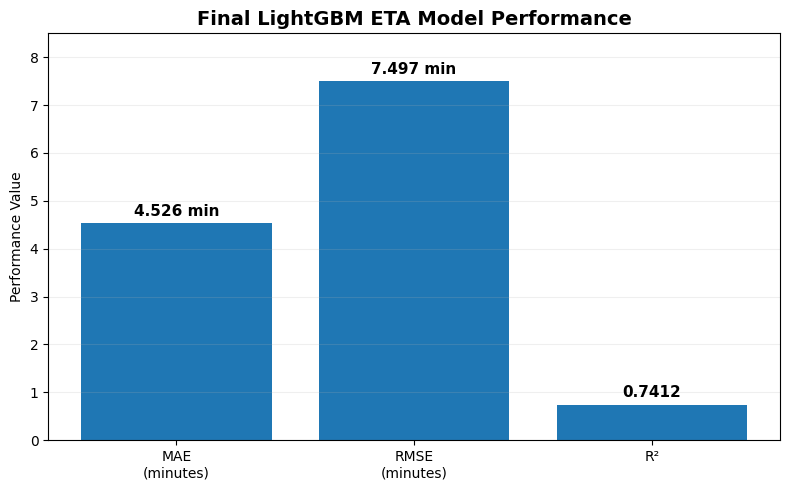

Saved: /content/drive/MyDrive/UrbanFlow_Datathon_2026/duration_model_v3/results/Final_LightGBM_MAE_RMSE_R2.png


In [74]:
import matplotlib.pyplot as plt

labels = [
    "MAE\n(minutes)",
    "RMSE\n(minutes)",
    "R²"
]

values = [
    4.526,
    7.497,
    0.7412
]

plt.figure(figsize=(8, 5))

bars = plt.bar(labels, values)

plt.title(
    "Final LightGBM ETA Model Performance",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Performance Value")
plt.ylim(0, 8.5)

for bar, value in zip(bars, values):
    text = (
        f"{value:.3f} min"
        if value > 1
        else f"{value:.4f}"
    )

    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.15,
        text,
        ha="center",
        fontweight="bold",
        fontsize=11
    )

plt.grid(axis="y", alpha=0.2)
plt.tight_layout()

save_path = (
    "/content/drive/MyDrive/UrbanFlow_Datathon_2026/"
    "duration_model_v3/results/"
    "Final_LightGBM_MAE_RMSE_R2.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", save_path)

,Metric,Result
0,Selected Model,LightGBM
1,Configuration,Config_A_Baseline
2,Final Training Rows,1841777
3,Number of Features,50
4,Boosting Iterations,858
5,Mean MAE (minutes),4.526
6,Mean RMSE (minutes),7.497
7,RMSE Std Dev,0.5104
8,Worst-Month RMSE (minutes),8.225
9,Mean R2,0.7412



Saved results table:
/content/drive/MyDrive/UrbanFlow_Datathon_2026/duration_model_v3/results/FINAL_ETA_REPORT_RESULTS.csv


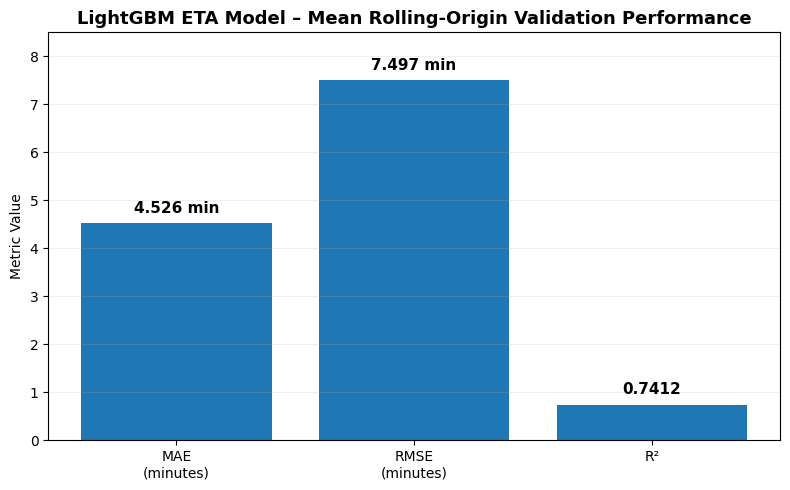


Saved graph:
/content/drive/MyDrive/UrbanFlow_Datathon_2026/duration_model_v3/results/FINAL_ETA_MODEL_PERFORMANCE.png

FINAL ETA MODEL RESULT

The selected LightGBM ETA model achieved a mean rolling-origin
validation MAE of 4.526 minutes, RMSE of 7.497 minutes, and
R² of 0.7412 across four temporal validation periods.

Approximately 18.22% of predictions were within ±1 minute,
49.96% were within ±3 minutes, and 70.95% were within ±5
minutes of the actual trip duration.

The final LightGBM model was refitted using 1,841,777
engineered observations, 50 predictor features, and
858 boosting iterations.



In [75]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# FINAL ETA RESULT — REPORT READY
# ============================================================

PROJECT_DIR = "/content/drive/MyDrive/UrbanFlow_Datathon_2026"
RESULT_DIR = f"{PROJECT_DIR}/duration_model_v3/results"

os.makedirs(RESULT_DIR, exist_ok=True)

# Final validated performance
final_results = {
    "Selected Model": "LightGBM",
    "Configuration": "Config_A_Baseline",
    "Final Training Rows": 1841777,
    "Number of Features": 50,
    "Boosting Iterations": 858,
    "Mean MAE (minutes)": 4.526,
    "Mean RMSE (minutes)": 7.497,
    "RMSE Std Dev": 0.5104,
    "Worst-Month RMSE (minutes)": 8.225,
    "Mean R2": 0.7412,
    "Within ±1 min (%)": 18.2161,
    "Within ±3 min (%)": 49.9621,
    "Within ±5 min (%)": 70.9510
}

# ============================================================
# 1. SAVE FINAL RESULTS TABLE
# ============================================================

result_table = pd.DataFrame({
    "Metric": list(final_results.keys()),
    "Result": list(final_results.values())
})

display(result_table)

csv_path = f"{RESULT_DIR}/FINAL_ETA_REPORT_RESULTS.csv"
result_table.to_csv(csv_path, index=False)

print("\nSaved results table:")
print(csv_path)

# ============================================================
# 2. FINAL REPORT GRAPH
# ============================================================

labels = [
    "MAE\n(minutes)",
    "RMSE\n(minutes)",
    "R²"
]

values = [
    4.526,
    7.497,
    0.7412
]

plt.figure(figsize=(8, 5))

bars = plt.bar(labels, values)

plt.title(
    "LightGBM ETA Model – Mean Rolling-Origin Validation Performance",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel("Metric Value")
plt.ylim(0, 8.5)
plt.grid(axis="y", alpha=0.20)

# Labels
display_values = [
    "4.526 min",
    "7.497 min",
    "0.7412"
]

for bar, text in zip(bars, display_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.15,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()

graph_path = f"{RESULT_DIR}/FINAL_ETA_MODEL_PERFORMANCE.png"

plt.savefig(
    graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nSaved graph:")
print(graph_path)

# ============================================================
# 3. PRINT REPORT-READY FINAL STATEMENT
# ============================================================

print("\n" + "=" * 70)
print("FINAL ETA MODEL RESULT")
print("=" * 70)

print("""
The selected LightGBM ETA model achieved a mean rolling-origin
validation MAE of 4.526 minutes, RMSE of 7.497 minutes, and
R² of 0.7412 across four temporal validation periods.

Approximately 18.22% of predictions were within ±1 minute,
49.96% were within ±3 minutes, and 70.95% were within ±5
minutes of the actual trip duration.

The final LightGBM model was refitted using 1,841,777
engineered observations, 50 predictor features, and
858 boosting iterations.
""")

print("=" * 70)